# DeepDive 6: Evaluating Transformer-Based Text Generation: A Comparative Study of BLEU Score and Validation Loss

### TABLE OF CONTENTS

1. [**Introduction**](#introduction)
2. [**Model Training**](#model-training)
3. [**Analysis**](#analysis)
4. [**Conclusion**](#conclusion)

## Introduction 

### **1. The Paradigm Shift in Sequence-to-Sequence Modeling**

### 1.1. The Bottlenecks of Legacy Sequence-to-Sequence Architectures

Prior to the Transformer era, sequence-to-sequence (Seq2Seq) tasks—such as dialogue generation and machine translation—relied heavily on Recurrent Neural Networks (RNNs), LSTMs, and GRUs within an encoder-decoder framework. These architectures struggled with severe inherent constraints:

* **The Sequential Bottleneck:** * RNN-based models process tokens strictly step-by-step from left to right.
  * Computation of the current hidden state $h_t$ is mathematically chained to the previous state $h_{t-1}$:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$


  * This recurrence creates an architectural roadblock preventing hardware-level parallelization during training.


* **The Fixed-Length Information Bottleneck:** 
  * The encoder was forced to compress the entire semantic meaning of a variable-length source sentence into a single, static context vector.
  * When processing long sentences or asymmetric input-output dialogue pairs, this vector acted as a critical choke point, causing severe data loss.


* **The Vanishing Gradient Problem:** 
  * Due to continuous recursive matrix multiplications backpropagated through time (BPTT), gradients vanished exponentially over long sequences.
  * This caused the model to "forget" early contextual tokens, destroying long-range dependencies.



### 1.2. Architectural Breakthroughs of the Transformer

By introducing *"Attention Is All You Need"* (Vaswani et al., 2017), the Transformer completely eliminated temporal recurrence. This structural overhaul unlocked multiple groundbreaking advantages beyond simply managing varying sequence lengths:

* **Structural Elimination of Length Discrepancies:**
  * Unlike RNNs, the Transformer processes entire token arrays concurrently.
  * Variable-length alignments are resolved instantly at a matrix level using dynamic masking mechanisms.
  * Short prompts yielding long responses (or vice versa) are mapped natively as an $N \times M$ matrix grid, discarding static context vectors.


* **Massive Training Parallelization:**
  * Because the dependency on $h_{t-1}$ is removed, all token representations across the entire training corpus are calculated simultaneously.
  * This allows modern GPU architectures to run at peak compute capacity, making it possible to scale models on massive datasets.


* **Constant Path Length for Long-Range Dependencies:**
  * In RNNs, information must travel forward through $t$ discrete steps to link token $1$ with token $t$.
  * The Transformer’s self-attention mechanism connects every single token directly to every other token in a single operational step.
  * This shortens the maximum forward/backward path length to $O(1)$, completely neutralizing the vanishing gradient problem.


* **Position-Aware Global Context (Positional Encoding):**
  * To compensate for the loss of sequential processing, static spatial coordinates are injected directly into token embeddings via **Positional Encodings**.
  * This allows the network to learn rich, non-linear global context without relying on rigid left-to-right recurrence.



#### **Comparison: Legacy Models vs. Transformer**

| Architectural Dimension | Legacy Seq2Seq Models (RNN / LSTM / GRU) | The Transformer Architecture |
| --- | --- | --- |
| **Token Processing Mode** | **Sequential:** Steps are calculated one token at a time from left to right. | **Concurrent / Parallel:** The entire sentence matrix is ingested simultaneously. |
| **Long-Range Dependencies** | **Weak:** Early sequence history fades due to the vanishing gradient problem. | **Perfect ($O(1)$ Path):** Every token retains a direct, uncorrupted link to all other positions. |
| **Context Transmission** | **Information Bottleneck:** Choked through a single, fixed-size context vector. | **Dynamic Matrix Routing:** Maps associations dynamically via Self and Cross Attention. |
| **Asymmetric Lengths ($N \neq M$)** | **Poor:** High degradation when input and output sequence lengths vary widely. | **Native:** Handled flexibly using dynamic matrix masking and padding configurations. |
| **Hardware Optimization** | **Inefficient:** Recurrence prevents scalable GPU parallel training. | **Optimal:** Highly optimized for modern distributed GPU acceleration systems. |

### **2. Architecture & Mathematical Overview**

### 2.1 Macro Architecture: The Encoder-Decoder Framework

The macro-topography of the Transformer architecture relies on the strategic coupling of an **Encoder** stack and a **Decoder** stack. The Encoder maps an input sequence of symbolic tokens to a sequence of continuous representations, while the Decoder generates an output sequence of tokens autoregressively, one step at a time. While seemingly a simple sequence of matrix operations, this structure maintains strict mathematical rules governing token-to-layer interactions.

#### 2.1.1 Token Dimensionality Preservation and Layer-Wise Information Evolution

The fundamental structural constraint flowing through the vertical pipeline of the Transformer is that **the tensor shape of token representations remains strictly invariant across all layers.**

* **Static Dimension Constraints ($d_{\text{model}}$):** When a source sentence is split into a sequence of $L_{\text{src}}$ tokens, each token is mapped to a continuous vector space of dimension $d_{\text{model}}$ via an embedding layer. The raw input matrix $X_{\text{enc}}$ satisfies the spatial bound:

$$X_{\text{enc}} \in \mathbb{R}^{L_{\text{src}} \times d_{\text{model}}}$$


* **Token-to-Layer Invariance:** As the data matrix passes vertically from Layer $1$ to the topmost Layer $N$, the tensor dimensions are strictly preserved at $(L_{\text{src}} \times d_{\text{model}})$. The architecture does not downsample or compress the sequence length $L_{\text{src}}$ as it climbs the stack.
* **Semantic Maturation:** While the tensor shape remains static, the information density within each token vector evolves. At the baseline layer, a token vector represents a rigid, isolated lexical embedding. As it ascends through subsequent layers, the vector absorbs surrounding relational context via self-attention, maturing into a high-density contextualized representation vector.

#### 2.1.2 Inter-Stack Binding: The Cross-Attention Bridge

The unique topological bridge connecting the Encoder and Decoder stacks occurs exclusively within the **Decoder-Encoder Cross-Attention** sub-layers embedded inside the Decoder blocks.

* **Transmission of the Encoded Context:** Let the final output matrix of the ultimate Encoder layer ($N$) be denoted as $H_{\text{enc}} \in \mathbb{R}^{L_{\text{src}} \times d_{\text{model}}}$. This matrix serves as a static, frozen semantic landscape for the Decoder.
* **Asymmetric Query, Key, and Value Mapping:** Inside the Cross-Attention sub-layer, the information-seeking vector—the **Query ($Q$)**—is linearly projected from the current Decoder intermediate hidden representations. Conversely, the reference indices—the **Keys ($K$)**—and the source data contents—the **Values ($V$)**—are both projected directly from the static Encoder output matrix $H_{\text{enc}}$:

$$Q = X_{\text{dec}} W^Q \in \mathbb{R}^{L_{\text{tgt}} \times d_k}$$


$$K = H_{\text{enc}} W^K \in \mathbb{R}^{L_{\text{src}} \times d_k}$$


$$V = H_{\text{enc}} W^V \in \mathbb{R}^{L_{\text{src}} \times d_v}$$



#### 2.1.3 Rule of Layer Independence: Mathematical Rationale for Asymmetric Stacks ($N \neq M$)

During hyperparameter optimization, the total depth of the Encoder stack ($N$) and the Decoder stack ($M$) can be configured completely independently (e.g., $N=4, M=6$) without causing any architectural or tensor-dimension conflicts.

* **The Mechanism of Layer Isolation:** Regardless of the depth of the Decoder stack ($M$), every single Cross-Attention sub-layer across all $M$ discrete decoder blocks references the exact same static topmost output matrix $H_{\text{enc}}$ from the Encoder.
* **Dimensional Alignment in Dot-Product Spaces:** The core mathematical operation mapping the cross-attention affinity matrix is calculated as:

$$\text{Attention Score Matrix} = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) \in \mathbb{R}^{L_{\text{tgt}} \times L_{\text{src}}}$$


The matrix multiplication $Q \times K^T$ requires the hidden projection dimension ($d_k$) of both vectors to match exactly. Because $d_k = d_{\text{model}} / h$ is a global constant tied to the model's base embedding width, a valid matrix dot product is unconditionally guaranteed at any layer depth.
* **Architectural Utility:** This structural flexibility allows developers to deliberately configure an asymmetric network—such as deploying a shallow, efficient Encoder alongside a deep, expressive Decoder—to handle complex target sequence generation tasks while conserving computational resources.


#### 2.1.4 Empirical and Scale-Driven Principles for Layer Depth Configuration

Choosing the optimal number of layers ($N$ and $M$) is governed by an empirical trade-off between representative capacity and optimization tractability. The configuration is primarily driven by three core vectors:

* **Data Volume and the Overfitting Threshold:** * The depth of the architecture scales proportionally with the number of unique training samples in the corpus.
  * Deep architectures (e.g., $N=6$ to $12$) possess millions of trainable parameters. If trained on a small, low-capacity dataset, the model will quickly memorize noise, leading to catastrophic **overfitting** where training loss drops to zero while validation loss degrades.
  * For smaller, specialized domain datasets (e.g., a localized dialogue script with fewer than 100,000 pairs), a compressed framework (such as $N=2$ or $N=4$) is strictly required to enforce regularization.


* **Semantic Complexity of the Target Task:**
  * The structural demand shifts depending on the cognitive difficulty of the sequence-to-sequence mapping.
  * Tasks that require complex syntactic transformation, reasoning, or cross-lingual structural alignment necessitate a deeper stack. Each additional layer allows the model to form higher-order abstractions.
  * In asymmetric dialogue applications (like a task-oriented chatbot), the Encoder is often designed to be shallower (e.g., $N=4$) because understanding the user prompt requires less compute than generating a highly fluent, grammatically flawless response, which might utilize a deeper Decoder (e.g., $M=6$).


* **Hardware Capacity and Inference Latency Footprints:**
  * Every added layer increases the computational graph quadratically during the autoregressive generation pass.
  * Because the Decoder must generate tokens sequentially, one by one, a model with a high layer count ($M \ge 12$) severely degrades real-time deployment latency. Depth configuration must balance the available modern GPU memory (VRAM) bounds with the target frames-per-second (FPS) delivery metrics.


#### **Summary Matrix for Depth Decision-Making**

| Dataset Scale | Task Complexity | Recommended Depth ($N \times M$) | Risk Factors |
| --- | --- | --- | --- |
| **Small** (< 50K samples) | Short QA / Fixed Templates | $2 \times 2$ or $4 \times 4$ (Lightweight) | High risk of overfitting if depth exceeds 6 layers. |
| **Medium** (100K - 1M samples) | Domain-Specific Chatbots / Style Transfer | $4 \times 4$ or $4 \times 6$ (Asymmetric) | Balanced tradeoff; standard baseline setup. |
| **Large** (> 10M samples) | Open-Domain Translation / General LLMs | $6 \times 6$ up to $12 \times 12$ and beyond | High compute costs; vanishing gradients require intense residual wiring. |


#### **Case Study of This Project: Structural Justification for a Single-Layer ($N=1, M=1$) Configuration:**
In this implementation, both the Encoder and Decoder stacks were deliberately restricted to a single-layer layout (`n_layers=1`). While production-grade Large Language Models (LLMs) scale up to 12 or 96 layers to capture massive web-scale corpora, a shallow single-layer approach provides specific mathematical and empirical advantages for this specialized chatbot task:
1. **Prevention of Attention Sinking and Overfitting:** Given the localized sample size of our conversational corpus, deeper stacks would instantly trigger aggressive parameter overfitting, leading to memorization rather than generalization.
2. **Algorithmic Interpretability:** Restricting the model depth to one layer isolates the core mathematical transformations. This ensures that the generated 16-panel evaluation attention grid directly reflects the pristine, unpolluted spatial relationships between the input tokens and the output sequence, bypassing the highly distorted abstractions inherent in deep, multi-layered representations.
3. **Optimization Efficiency:** It severely curtails the computational graph complexity, preventing backpropagation vanishing routes and enabling rapid parameter stabilization across the 50-epoch cycle under limited hardware constraints.

### 2.2 Micro-Component Diagnostics: Sub-Layers and Regularization Foundations

Within each structural layer block of the Transformer, data does not simply pass through attention modules. Instead, it flows through a tightly integrated micro-ecosystem composed of **Feed-Forward Networks (FFN)**, **Residual Connections (Skip Connections)**, and **Layer Normalization (LayerNorm)**. The allocation of these regularization and transformation parts is strictly dictated by a 1:1 structural pairing with the network's sub-layers.

#### 2.2.1 Topological Quantities and Structural Matching Rules

To map out the exact quantities of these components, the architecture defines every major operational block (Self-Attention, Cross-Attention, and FFN) as an independent **Sub-Layer**.

* **The 1:1:1 Sub-Layer Mapping Rule:** For every single Sub-Layer inside the Transformer, there must be exactly **one parallel Residual Connection** wrapped around it and **one matching LayerNorm module** stabilizing its inputs or outputs.
* **Inside a Single Encoder Layer:** Contains **2 Sub-Layers** (1. Self-Attention, 2. FFN).
* *Component Quantities:* Exactly **1 FFN, 2 LayerNorm blocks, and 2 Residual paths**.


* **Inside a Single Decoder Layer:** Contains **3 Sub-Layers** (1. Masked Self-Attention, 2. Decoder-Encoder Cross-Attention, 3. FFN).
* *Component Quantities:* Exactly **1 FFN, 3 LayerNorm blocks, and 3 Residual paths**.



**Total Component Distribution**

Because these blocks are bound to the internal sub-layer blueprint, their totals scale linearly with network depth ($N$ and $M$). For a network built with $N$ Encoder layers and $M$ Decoder layers, the distribution is explicitly defined as:


$$\text{Total Encoder Pack} = N \times (1 \text{ FFN} + 2 \text{ LayerNorm} + 2 \text{ Residuals})$$

$$\text{Total Decoder Pack} = M \times (1 \text{ FFN} + 3 \text{ LayerNorm} + 3 \text{ Residuals})$$

Given that this project explicitly utilizes a single-layer baseline layout ($N=1, M=1$), the complete execution graph across your code contains exactly **2 FFNs, 5 LayerNorm modules, and 5 Residual tracking paths** in total.


* **Why only 1 FFN per layer?** The Transformer architecture separates duties. The Attention sub-layer shuffles and mixes information *between* different tokens (spatial routing). The FFN sub-layer then processes that mixed information *within* each token independently (feature transformation). Doing this once per layer block is mathematically sufficient to complete one full cycle of contextual updating.
* **Is LayerNorm linked to the number of attentions?** Yes, directly. Every attention block (and every FFN block) counts as an independent **Sub-Layer**. Because the Transformer uses a strict "Normalize before/after a Sub-Layer" infrastructure layout, the number of LayerNorm modules is tied to the total count of attention and FFN modules combined.
* **Is the count of Residual Connections identical to LayerNorm?** Yes. Every single Sub-Layer that requires a LayerNorm also requires a parallel Residual (skip) path wrapped around it to preserve the gradient highway. Therefore, their quantities match perfectly.



#### 2.2.2 Position-Wise Feed-Forward Networks (FFN)

While attention mechanisms map the relational context *between* distinct tokens, they are purely linear weighted combinations. The FFN sub-layer is strategically placed once at the end of each layer block to apply non-linear transformations to each token vector independently and identically at all positions.

**The Mathematical Rationale for a Single FFN Pass**

An attention pass merely shuffles existing token vectors based on similarity scores. To actually update the internal features of a token and store learned semantic knowledge, the model needs a dedicated non-linear processing stage. Running **one FFN pass per layer block** is mathematically optimal because it allows the model to instantly project the freshly mixed attention context into a high-dimensional feature space, inject non-linearity, and compress it back down before passing it to the next structural block.

**A. Mathematical Formulations**

The FFN consists of two linear transformations with a non-linear activation function applied in between:


$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$


Where:

* $x \in \mathbb{R}^{1 \times d_{\text{model}}}$ is the hidden representation of a single token at a given sequence position.
* $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$ projects the vector up into a higher-dimensional space (typically $d_{\text{ff}} = 4 \times d_{\text{model}}$).
* $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$ projects the expanded representation back down to the core model dimension.

**B. Absolute Necessity and Trade-offs**

* **Why it is Mandatory:** Without the FFN, the entire Transformer would collapse into a massive, highly constrained linear regression engine. The attention weights would merely shuffle the original input spaces around. The FFN introduces the high-degree non-linearity needed to extract complex semantic concepts and map abstract chatbot vocabulary distributions.


#### 2.2.3 Residual (Skip) Connections

A Residual Connection adds the original input of a sub-layer directly back to its computed output, bypassing the transformations inside that specific module.

**A. Mathematical Formulations**

For a given sub-layer function $\text{SubLayer}(x)$ (such as an attention or FFN module), the output of the residual step is formulated as:


$$\text{Output}_{\text{residual}} = x + \text{SubLayer}(x)$$

**B. Absolute Necessity and Trade-offs**

* **Why it is Mandatory:** As tokens pass through multi-stage non-linear transformations, information degradation occurs. Residual connections establish an uninterrupted, pristine high-speed information highway across the model. During backpropagation, the derivative of $x + \text{SubLayer}(x)$ with respect to $x$ injects a constant term $+1$ into the gradient chain rule:

$$\frac{\partial}{\partial x}(x + \text{SubLayer}(x)) = 1 + \frac{\partial \text{SubLayer}(x)}{\partial x}$$


This constant $+1$ guarantees that gradients can flow backwards completely unhindered, neutralizing the risk of the **vanishing gradient problem**.


### 2.2.4 Layer Normalization (LayerNorm)

LayerNorm standardizes the activations across the hidden features dimension for each individual token independently, ensuring that the scale of inputs to subsequent layers remains highly consistent.

**A. Mathematical Formulations**

Given a token vector $x \in \mathbb{R}^{d_{\text{model}}}$, LayerNorm computes the mean $\mu$ and variance $\sigma^2$ across its $d_{\text{model}}$ elements:


$$\mu = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} x_i, \quad \sigma^2 = \frac{1}{d_{\text{model}}} \sum_{i=1}^{d_{\text{model}}} (x_i - \mu)^2$$


The vector elements are then standardized and linearly shifted using learned scale ($\gamma$) and bias ($\beta$) parameters:


$$\text{LayerNorm}(x) = \gamma \odot \left( \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \right) + \beta$$


Where $\epsilon$ is a tiny constant preventing division-by-zero errors, and $\odot$ denotes element-wise multiplication.

**B. Operational Necessity and Trade-offs**

While Layer Normalization is theoretically non-mandatory for the core geometric mapping of token embeddings, it remains practically indispensable for optimization stability. Rather than modifying feature dimensions, LayerNorm actively standardizes activation scales across the hidden dimension ($d_{\text{model}}$). Without this stabilization sub-layer, severe Internal Covariate Shift would trigger immediate numerical overflows or gradient explosions during backpropagation, causing the 50-epoch optimization graph to diverge catastrophically.

* **Pros:** Neutralizes activation variance, stabilizes optimization trajectories, and decouples token scaling from batch size dependencies.
* **Cons:** Incurs minor floating-point overhead during every forward and backward execution pass.


#### **Structural Impact Summary**

| Micro-Component | Essential Role | If Completely Removed (General Theory) | Impact on 1-Layer Model When Removed |
| --- | --- | --- | --- |
| **FFN Sub-Layer** | Injects high-degree non-linearity and token feature expansion. | Model fails to fit semantic structures; sentences lack expressiveness. | **Fatal:** The model will fail to output coherent chatbot responses. |
| **Residual Path** | Preserves gradient vitality and provides a raw data highway. | Gradients choke during backpropagation, leading to early training stall. | **Moderate:** Training would slow down significantly even at 1-layer. |
| **LayerNorm** | Stabilizes vector distributions and controls internal shift. | Activations scale out of control, triggering catastrophic training divergence. | **Fatal:** Numerical overflows will crash the tensor execution graph. |

### 2.3 Mathematical Foundation: Positional Encoding and Vector Alignments
#### 2.3.1 Architectural Rationale and Mathematical Formulation

To enable the network to learn positional relationships, a fixed coordinate mapping system based on sine and cosine functions of different frequencies is utilized. For a given token position $\text{pos}$ and a feature dimension index $i$ within the hidden dimension $d_{\text{model}}$, the positional encoding ($\text{PE}$) is formulated as:

$$\text{PE}_{(\text{pos}, 2i)} = \sin\left(\frac{\text{pos}}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

$$\text{PE}_{(\text{pos}, 2i+1)} = \cos\left(\frac{\text{pos}}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

**Vector Alignment Mechanics: Why Positional Encoding Is Added**

The final input matrix $X \in \mathbb{R}^{L \times d_{\text{model}}}$ fed into the primary attention block is generated via element-wise addition rather than horizontal concatenation:


$$X = E + \text{PE}$$


While it initially appears that adding coordinates directly to semantic features might corrupt the word embedding spaces, the linear projections inside the Multi-Head Attention layers prevent this corruption. When $X$ is multiplied by the learned weight matrices ($W^Q, W^K, W^V$), the operation decomposes linearly:


$$XW^Q = (E + \text{PE})W^Q = EW^Q + \text{PE}W^Q$$


This decomposition demonstrates that the learned linear projection layers separate the semantic components ($EW^Q$) from the structural positional components ($\text{PE}W^Q$) within the high-dimensional subspace, allowing the model to optimize both signals simultaneously.

**Structural Breakdown: Why Concatenation Is Rejected for PE**

An alternative approach would be to concatenate the matrices horizontally, creating an expanded representation:


$$X_{\text{concat}} = [E \; ; \; \text{PE}] \in \mathbb{R}^{L \times (d_{\text{model}} + d_{\text{pos}})}$$

* **Parameter and Memory Inflation:** Concatenation expands the hidden width of every downstream sub-layer, including the Feed-Forward Network and the Multi-Head Attention linear projection layers. This increases the total parameter volume and memory overhead across the computational graph.
* **Disruption of Residual Highways:** The Transformer relies on strict tensor shape invariance to execute residual connections ($x + \text{SubLayer}(x)$). If concatenation were utilized, changing the embedding dimensions mid-stack would require additional projection matrices, destroying the parameter-efficient, streamlined information highway.
* **High-Dimensional Orthogonality:** In a high-dimensional vector space (such as $d_{\text{model}} = 256$), random or structured vectors are naturally close to orthogonal. By adding $\text{PE}$ to $E$, the positional signal is embedded as a distinct directional shift that the network can easily isolate without expanding the physical width of the tensor layouts.


#### 2.3.2 Taxonomy of Tensor Combinations: Addition vs. Concatenation in Transformer Sub-Systems

While Positional Encoding utilizes element-wise addition to preserve vector shapes and prevent parameter inflation, the broader Transformer architecture selectively employs both **Addition** and **Concatenation** depending on the functional requirements of each sub-system.

```
[Embedding Matrix (L x d)] ----+
                               |---> (Element-wise Addition) ---> Input Matrix X
[Positional Encoding (L x d)] -+

```

```
[Head 1 Attention (L x d_k)] ---+
[Head 2 Attention (L x d_k)] ---|---> (Horizontal Concatenation) ---> Combined Matrix (L x d_model)
[Head h Attention (L x d_k)] ---+

```

**1. Operations Utilizing Element-Wise Addition**

Beyond Positional Encodings, addition is exclusively used in **Residual Connections (Skip Connections)**:


$$\text{Output}_{\text{residual}} = x + \text{SubLayer}(x)$$

* **Mathematical Rationale:** The primary goal of a residual connection is to preserve pristine gradient flow during backpropagation. Adding the identity vector $x$ directly to the transformed output ensures that the derivative with respect to the input contains a constant $+1$ term ($\frac{\partial}{\partial x} \text{Output} = 1 + \frac{\partial \text{SubLayer}}{\partial x}$). This setup allows gradients to flow backward unimpeded without altering the tensor shape, maintaining strict compatibility with downstream LayerNormalization blocks.

**2. Operations Utilizing Horizontal Concatenation**

Concatenation is strategically applied at the output stage of **Multi-Head Attention (MHA)** sub-layers:


$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \text{head}_2, \dots, \text{head}_h)W^O$$

* **Mathematical Rationale:** Each independent attention head $\text{head}_i$ operates in a compressed, low-dimensional subspace where $\text{head}_i \in \mathbb{R}^{L \times d_k}$ (where $d_k = d_{\text{model}} / h$). Because each head captures a distinctly different linguistic relationship (e.g., syntactic vs. semantic dependencies), adding them together would blend and corrupt these separate channels of information.
* **Dimension Reconstruction:** To preserve the unique context learned by each individual head, they are concatenated horizontally to perfectly reconstruct the original model dimension:

$$h \times d_k = h \times \left(\frac{d_{\text{model}}}{h}\right) = d_{\text{model}}$$



The concatenated matrix $\mathbb{R}^{L \times d_{\text{model}}}$ is then multiplied by the final output weight matrix $W^O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$ to linearly blend the insights from all heads before passing the vector to the Feed-Forward Network.


#### 2.3.3 Sequence Bound Constraints ($L$) and Tensor Masking Mechanics

The maximum sequence length $L$ is a fixed hyperparameter established during the data preprocessing phase to enforce standard static tensor dimensions across parallel mini-batches.

**1. Padding and Static Allocation Bound**

Every input matrix is bound to a static shape constraint ($L \times d_{\text{model}}$). Sentences falling short of this limit are padded with `<pad>` tokens, while longer sentences undergo truncation. This consistency prevents memory allocation shifts inside the GPU during execution loops.

**2. Mathematical Masking Equations**

To prevent the fixed padding tokens from corrupting the attention distributions, and to preserve causality within the Decoder, two distinct mathematical masking operations are applied to the scaled dot-product matrix prior to the softmax activation:

$$\text{Attention Score Matrix} = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)$$

Where $M$ represents the attention mask matrix. The value of $M_{ij}$ is determined dynamically based on the mask type:

* **Encoder Padding Mask:** Applied to both Encoder Self-Attention and Decoder-Encoder Cross-Attention layers to block token interaction with meaningless padding vectors:

$$M_{ij} = \begin{cases} 0, & \text{if token } j \text{ is a valid sequence word} \\ -\infty, & \text{if token } j \text{ is a } \langle\text{pad}\rangle \text{ token} \end{cases}$$


* **Decoder Causal Mask (Look-Ahead Mask):** Applied exclusively within Decoder Self-Attention layers to enforce the autoregressive property, ensuring that the prediction for the current token depends only on known past tokens:

$$M_{ij} = \begin{cases} 0, & \text{if } j \le i \\ -\infty, & \text{if } j > i \end{cases}$$



**The Logit-Level Softmax Neutralization**

When the mask matrix element $M_{ij} = -\infty$ is added to the raw logit dot product, the subsequent softmax evaluation mathematically neutralizes the position's influence:

$$e^{-\infty} \to 0 \implies \text{softmax}\left(\frac{Q_i K_j^T}{\sqrt{d_k}} -\infty\right) = 0$$

This operation ensures that masked positions receive an attention coefficient of exactly zero, completely isolating invalid or future tokens from the gradient path and sequence generation stream.

### 2.4 Taxonomy of Attention Mechanisms: Structural and Vector Origins

To comprehend the information routing within the Transformer, the architecture must be classified into three distinct attention sub-layers. While all three share the foundational role of mapping context, they differ entirely in their structural execution, their location within the stack, and the geographic origins of their **Query ($Q$)**, **Key ($K$)**, and **Value ($V$)** vectors.

#### 2.4.1 Clarifying Vector Identity: Origin vs. Value

A frequent point of confusion in Transformer analysis is the mathematical definition of equality when stating $Q = K = V$.

* **The Rule of Co-Origin:** In these equations, "equality" indicates that the vectors share the **exact same geographical source or embedding pool** within the neural network pipeline.
* **Distinct Numerical Values:** They do **not** share identical numerical coordinate values. Even if a single token (e.g., `"tired"`) provides the origin for $Q$, $K$, and $V$, it is multiplied by three entirely separate, independently trained weight matrices ($W^Q, W^K, W^V$).
* **Numerical Illustration:** Let an input token embedding be $x = [1.0, -0.5]$. Even though the source is identical, the linear projections yield entirely different spatial vectors:

$$Q = x \cdot W^Q = [1.0, -0.5] \times \begin{bmatrix} 0.1 & 0.8 \\ -0.2 & 0.4 \end{bmatrix} = [0.2, 0.6]$$


$$K = x \cdot W^K = [1.0, -0.5] \times \begin{bmatrix} 0.5 & -0.1 \\ 0.3 & 0.9 \end{bmatrix} = [0.35, -0.55]$$


$$V = x \cdot W^V = [1.0, -0.5] \times \begin{bmatrix} -0.4 & 0.2 \\ 0.7 & 0.0 \end{bmatrix} = [-0.75, 0.2]$$


* Thus, while the **origin** is identical, $Q \neq K \neq V$ in numerical space.





#### 2.4.2 The Three Attention Core Variants

The structural breakdown of the three operations across the pipeline is formalized below:

**1. Encoder Self-Attention**

* **Location:** Enacted exclusively within the internal sub-layers of the Encoder stack.
* **Vector Vector Mapping:** $\text{Query} = \text{Key} = \text{Value}$
* **Origin Boundary:** Every vector ($Q, K, V$) is derived from the **Encoder input sequence matrix**. The layer maps relationships within the source text.

**2. Decoder Masked Self-Attention**

* **Location:** Enacted within the primary baseline sub-layer of the Decoder stack.
* **Vector Vector Mapping:** $\text{Query} = \text{Key} = \text{Value}$
* **Origin Boundary:** Every vector ($Q, K, V$) is derived from the **Decoder target sequence matrix**. However, a causal directional constraint is added to prevent the query from looking at future token positions.

**3. Decoder-Encoder Cross-Attention**

* **Location:** Enacted within the intermediate second sub-layer of the Decoder stack.
* **Vector Vector Mapping:** $\text{Query} \neq \text{Key} = \text{Value}$
* **Origin Boundary:** This is an asymmetric matching bridge.
* **Query ($Q$):** Projected exclusively from the **Decoder intermediate matrix** (the target response context).
* **Keys ($K$) and Values ($V$):** Projected exclusively from the **final static Encoder output matrix** (the source prompt context).





#### 2.4.3 Concrete Scenario Analysis: Contextual Mapping in Action

To demonstrate what these structural sub-layers look like during chatbot execution, consider the following live conversational interaction sequence:

* **Source Input (Encoder):** `"I woke up early today, so I am incredibly tired."`
* **Target Output (Decoder Generation Track):** `<start> You should rest <end>`

The following breakdown illustrates exactly what each specific attention channel tracks during execution:

**Execution Profile 1: Encoder Self-Attention**

* **What it looks at:** 
  * Maps connections strictly within the source sentence array.
* **Specific Tracking Behavior:** 
  * When processing the query token $Q = \text{"tired"}$, the mechanism sweeps across all available source keys ($K = \text{["I", "woke", "up", "early", "today", "so", "I", "am", "incredibly", "tired"]}$).
*  Labeled Target Spoting: 
   *  It maps a high weight link between the query $Q=\text{"tired"}$ and the keys $K=\text{"early"}$ and $K=\text{"woke up"}$, allowing the model to mathematically establish the *causal reason* for the tiredness within the source embedding.

**Execution Profile 2: Decoder Masked Self-Attention**

* **What it looks at:** 
  * Maps connections strictly within the tokens generated so far by the decoder, blocking future words.
* **Specific Tracking Behavior:** 
  * Assume the decoder has generated up to the word `"rest"`. The query token $Q = \text{"rest"}$ searches backwards across the targets generated so far ($K = \text{["<start>", "You", "should", "rest"]}$).
*  Labeled Target Spoting: 
   *  It binds $Q=\text{"rest"}$ heavily to $K=\text{"should"}$ and $K=\text{"You"}$, verifying that the generated phrase maintains correct grammar and syntactic agreement up to the current timestamp.

**Execution Profile 3: Decoder-Encoder Cross-Attention**

* **What it looks at:** 
  * Bridges the target token back to the original source prompt.
* **Specific Tracking Behavior:** 
  * The current decoder vector acting as the query is $Q = \text{"rest"}$. It reaches completely across the network to search the keys generated by the encoder ($K = \text{["I", "woke", "up", "early", "today", "so", "I", "am", "incredibly", "tired"]}$).
*  Labeled Target Spoting: 
   *  The decoder query $Q=\text{"rest"}$ highlights and links directly onto the encoder source key $K=\text{"tired"}$. This informs the model that the semantic concept of "resting" is being triggered specifically because the user stated they were "tired," effectively bridging the chatbot's response directly to the user's intent.



#### 2.4.4 Paradigmatic Evolution from Legacy Seq2Seq Attention

This decentralization of attention marks a complete structural departure from legacy **RNN-based Seq2Seq + Attention** models:

* **Legacy Limitations:** 
  * In an LSTM-Seq2Seq framework, attention occurred exactly *once* per step. The decoder hidden state at step $t$ acted as a single Query, checking against the historical hidden states of the encoder (functioning as Keys/Values). There was no mechanism for the encoder words to attend to each other independently, nor could decoder tokens self-correct their internal context.
* **The Transformer Advantage:** 
  * By distributing independent Self-Attention layers within both the Encoder and Decoder alongside the Cross-Attention bridge, the Transformer treats attention as a continuous, omnidirectional routing fabric. This allows tokens to constantly refine their meanings based on their surroundings before any inter-stack mapping occurs.

### 2.5 Algorithmic Execution of Attention: Scaled Dot-Product and Multi-Head Synthesis

While Section 2.4 established the qualitative origins of Queries, Keys, and Values, Section 2.5 details the exact mathematical execution of these vectors. Every attention sub-layer in the Transformer—whether Self, Masked, or Cross—processes these vectors through a unified, standardized algebraic sequence: **Linear Projection $\rightarrow$ Scaled Dot-Product Mapping $\rightarrow$ Multi-Head Subspace Splitting $\rightarrow$ Concat Matrix Reconstruction**.

#### **Step 1: Linear Projection and Tensor Space Alignment**

Before any token-to-token similarity is measured, the incoming hidden representation matrix $X \in \mathbb{R}^{L \times d_{\text{model}}}$ must be transformed into distinct functional spaces.

* **Learned Parameter Projections:** The model utilizes three completely independent weight matrices to project the single source matrix $X$ into its operational components:

$$Q = X \cdot W^Q \in \mathbb{R}^{L \times d_{\text{model}}}$$


$$K = X \cdot W^K \in \mathbb{R}^{L \times d_{\text{model}}}$$


$$V = X \cdot W^V \in \mathbb{R}^{L \times d_{\text{model}}}$$



Where $W^Q, W^K, W^V \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$ are learned parameter tensors. This step alters the geometric orientation of the vectors, ensuring that even if $Q, K,$ and $V$ share the same origin, their numerical coordinates diverge to serve different functional tasks.


#### **Step 2: The Scaled Dot-Product Operation**

Once $Q, K,$ and $V$ are established, they enter the core algebraic pipeline of the Transformer. The complete mathematical formula is defined as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V$$

This equation decomposes into three distinct sequential matrix operations:

* **Matrix Dot-Product Similarity ($QK^T$):** 
  * The Query matrix ($\mathbb{R}^{L \times d_{\text{model}}}$) is multiplied by the transposed Key matrix ($\mathbb{R}^{d_{\text{model}} \times L}$).
  * This generates a raw **Attention Score Matrix (Logits)** of shape $\mathbb{R}^{L \times L}$.
  * This matrix directly represents the raw, unnormalized compatibility score between every token position $i$ and every token position $j$ in the sequence. It is computed dynamically at a **token-to-token** level inside every layer.


* **The Variance Scaling Factor ($\sqrt{d_k}$):**
  * As the vector dimension $d_k$ grows large, the dot products grow extremely large in magnitude. This pushes the subsequent softmax function into regions with dangerously small gradients, causing the **vanishing gradient problem** during training.
  * Dividing the matrix elements by $\sqrt{d_k}$ standardizes the variance back to $1$, stabilizing numerical propagation.


* **Softmax Soft Distribution and Value Weighting:**
  * The scaling output (and the optional mask matrix $M$ detailed in Section 2.3.3) passes through a row-wise Softmax function.
  * This converts the raw logits into a probabilistic distribution where every row sums to exactly $1.0$. This normalized matrix is the **Attention Weight Matrix**—the exact footprint visualized in our 16-panel evaluation grid.
  * Finally, this weight matrix ($\mathbb{R}^{L \times L}$) is multiplied by the Value matrix $V$ ($\mathbb{R}^{L \times d_{\text{model}}}$) to generate the final contextualized token matrix ($\mathbb{R}^{L \times d_{\text{model}}}$).




#### **Step 3: Multi-Head Subspace Splitting and Synthesis**

To prevent the model from focusing on only a single type of relationship across the sequence, the Transformer breaks the global $d_{\text{model}}$ space into $h$ independent, parallel channels called **Heads**.

* **The Dimensional Dimension Formula ($d_k$):** Given the base configuration of this model ($d_{\text{model}} = 256$ and $h = 8$), the key dimensionality for each individual head is calculated via:

$$d_k = d_v = \frac{d_{\text{model}}}{h} = \frac{256}{8} = 32$$


* **Parallel Subspace Execution:** Rather than computing attention on a massive $256 \times 256$ matrix, the tensors are sliced into $8$ independent sets of lower-dimensional matrices:

$$\text{head}_i = \text{Attention}\left(QW_i^Q, KW_i^K, VW_i^V\right) \in \mathbb{R}^{L \times d_k}$$



Each head uses distinct projection weights ($W_i^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$), allowing Head 0, Head 1, up to Head 7 to track completely different contextual dependencies (e.g., matching verbs to nouns vs. tracking punctuation bounds) concurrently.


#### **Step 4: Horizontal Concatenation and Output Reconstruction**

After all $h=8$ independent heads complete their individual scaled dot-product routines, their isolated output matrices ($Z_i \in \mathbb{R}^{L \times 32}$) must be unified to pass into the downstream Feed-Forward Network.

* **Horizontal Combination (Concat):** The $8$ individual matrices are concatenated horizontally side-by-side:

$$\text{Combined Matrix} = \text{Concat}(\text{head}_1, \text{head}_2, \dots, \text{head}_8) \in \mathbb{R}^{L \times (8 \times 32)} \implies \mathbb{R}^{L \times 256}$$



This step perfectly reconstructs the original spatial dimension $d_{\text{model}} = 256$ without adding or dropping token vectors.
* **The Final Linear Blend ($W^O$):** To ensure that the insights discovered by individual heads are not left isolated, the concatenated matrix is passed through a final linear output projection matrix $W^O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$:

$$\text{MultiHead}(Q, K, V) = \text{Combined Matrix} \cdot W^O \in \mathbb{R}^{L \times d_{\text{model}}}$$



This operation blends the multi-perspective features back into a single, cohesive representation vector per token, preserving structural shape invariance before hitting the LayerNorm and FFN blocks.


#### **Token and Layer Processing Chronology**

To finalize the introduction, the structural frequency of every mathematical transformation across the execution graph is explicitly detailed below:

| Computational Target | Update Frequency / Nature | Tensor Shape Invariance |
| --- | --- | --- |
| **Weight Matrices ($W^Q, W^K, W^V$)** | Static per layer; learned during backpropagation. | Fixed dimension matrices bounded by $d_{\text{model}}$. |
| **Attention Logits ($QK^T$)** | Calculated dynamically **per layer and per token pair** at every forward pass. | $L \times L$ square grid changing values with every sequence. |
| **Subspace Split ($d_k$)** | Calculated natively by slicing the hidden model width by the head parameter $h$. | $L \times (d_{\text{model}}/h)$ matrix channels. |
| **Final Layer Output** | Reconstructed perfectly via horizontal concatenation and $W^O$ projection. | Restored strictly to $L \times d_{\text{model}}$ to match residual inputs. |

### 2.6 The Final Output Pipeline: Linear Mapping, Softmax Vocabulary Projection, and Autoregressive Inference

After the hidden representations pass through the final sub-layers of the Decoder stack, the vectors must be mapped back into token space to generate readable language. This ultimate stage transforms continuous high-dimensional internal embeddings into discrete probability distributions over the entire vocabulary, driven by a sequential, autoregressive decoding loop.

#### 2.6.1 Linear Vocabulary Mapping (The Classification Head)

The output of the final Decoder layer for a single token position is a contextualized vector $z_{\text{final}} \in \mathbb{R}^{1 \times d_{\text{model}}}$. To determine which word from the dictionary this vector represents, it must be projected into the vocabulary space.

* **The Vocabulary Weight Tensor ($W_{\text{vocab}}$):** The model passes $z_{\text{final}}$ through a final, unnormalized linear layer (often called the Language Modeling Head):

$$\text{Logits} = z_{\text{final}} \cdot W_{\text{vocab}} + b_{\text{vocab}}$$



Where $W_{\text{vocab}} \in \mathbb{R}^{d_{\text{model}} \times |V|}$ and $b_{\text{vocab}} \in \mathbb{R}^{|V|}$ represent the learned weights and biases, and $|V|$ is the absolute size of the vocabulary (the total number of unique tokens in the chatbot's dictionary).
* **The Logit Vector:** This operation produces a raw score vector (logits) of shape $\mathbb{R}^{1 \times |V|}$, where every single word in the entire dictionary receives a raw numerical value indicating its generation compatibility.


#### 2.6.2 Softmax Categorical Distribution and Token Selection

To convert the unnormalized logits into valid probabilities, the vector is passed through a global Softmax activation function.

* **Probability Formulation:** The probability of selecting a specific token $k$ from the vocabulary at the current decoding step is mathematically defined as:

$$P(\text{token} = k \mid \text{context}) = \frac{e^{\text{Logits}_k}}{\sum_{j=1}^{|V|} e^{\text{Logits}_j}}$$


* **Greedy Decoding Mechanism:** During standard execution and evaluation tracking, the model selects the token with the absolute highest probability score via an `argmax` operation:

$$\hat{y} = \arg\max_{k} \left( P(\text{token} = k \mid \text{context}) \right)$$



This selected index $\hat{y}$ is then mapped back to its corresponding string representation (e.g., converting index `402` back into the word `"rest"`) using the inverse token vocabulary map.



#### 2.6.3 The Mechanics of Autoregressive Inference

While the Encoder processes the entire source prompt concurrently in parallel, the Decoder must operate **autoregressively** during inference. This means the model generates the final response text iteratively, token by token.

```
Step 1: Input: ["<start>"] ------------------------> Model Prediction: "You"
Step 2: Input: ["<start>", "You"] -----------------> Model Prediction: "should"
Step 3: Input: ["<start>", "You", "should"] --------> Model Prediction: "rest"
Step 4: Input: ["<start>", "You", "should", "rest"] -> Model Prediction: "<end>" (Termination)

```

* **The Step-by-Step Loop:**
1. The inference cycle is initiated by feeding a single starting token, `<start>`, into the Decoder alongside the static Encoder context matrix $H_{\text{enc}}$.
2. The model executes a full forward pass and predicts the first word (e.g., `"You"`).
3. For the next step, the newly predicted token is appended to the Decoder's input array, making the new input sequence `["<start>", "You"]`.
4. This expanded sequence is fed back into the Decoder to predict the subsequent token (`"should"`).


* **Halting Condition:** This recursive loop continues dynamically until the model outputs the explicit end-of-sequence token, `<end>`, or until the sequence hits the maximum pre-defined bounding length $L$.

### 2.7 Structural Configuration: Hyperparameter Taxonomy and Scalability

The behavior, capacity, and computational footprint of the Transformer are strictly governed by a set of user-defined structural hyperparameters. While the original architecture proposed by Vaswani et al. (2017) established specific baseline scales for massive machine translation datasets, these variables can be arbitrarily configured and scaled down to adapt to localized hardware limitations and smaller specialized chatbot corpora.

#### 2.7.1 Core Hyperparameter Definitions and Geometric Scaling

* **$d_{\text{model}}$ (Model Dimension / Embedding Width):**
  * **Definition:** Represents the fixed size of the input and output vectors across both the Encoder and Decoder stacks. Every token embedding matrix and intermediate sub-layer representation maintains this precise dimensional width to preserve tensor shape invariance.
  * **Baseline Literature Metric:** $d_{\text{model}} = 512$
  * **Architectural Tuning:** Reducing this parameter (e.g., to $256$ or $128$) linearly downscales the capacity of the model's token representations, reducing VRAM consumption at the expense of semantic granularity.


* **$N_{\text{layers}}$ (Stack Depth Count):**
  * **Definition:** Defines the total number of identical encoder and decoder blocks stacked vertically within their respective sub-systems.
  * **Baseline Literature Metric:** $N = 6$ (6 Encoder layers and 6 Decoder layers arranged sequentially).
  * **Architectural Tuning:** As established in Section 2.1.4, adjusting this to a shallow single-layer setup ($N=1$) acts as an intense regularization mechanism to prevent overfitting on low-capacity conversational datasets.


* **$h$ (Number of Parallel Attention Heads):**
  * **Definition:** Dictates the total number of multi-perspective subspaces into which the primary $d_{\text{model}}$ dimension is partitioned for parallel Scaled Dot-Product Attention operations.
  * **Baseline Literature Metric:** $h = 8$
  * **Architectural Tuning:** This value must always be a perfect divisor of $d_{\text{model}}$ to ensure the derived key dimensionality ($d_k = d_{\text{model}} / h$) results in an integer, preventing fractional tensor slicing errors during matrix execution.


* **$d_{\text{ff}}$ (Feed-Forward Hidden Dimension):**
  * **Definition:** Represents the width of the internal hidden layer within the position-wise Feed-Forward Network (FFN). While the input and output boundaries of the FFN are bound to $d_{\text{model}}$, the internal layer expands the vector space to map non-linear relationships.
  * **Baseline Literature Metric:** $d_{\text{ff}} = 2048$ (Typically configured as $4 \times d_{\text{model}}$).
  * **Architectural Tuning:** Squeezing or stretching this inner width directly regulates the capacity of the network's non-linear pattern storage mechanism.



#### 2.7.2 Mathematical Dependency and Configuration Interlocking

These four hyperparameters are mathematically interlocked. Altering a single value automatically shifts the execution bounds of downstream sub-layers across the entire training graph:

$$\text{Total Parameters}_{\text{MHA Block}} = 4 \times d_{\text{model}}^2$$

$$\text{Total Parameters}_{\text{FFN Block}} = 2 \times d_{\text{model}} \times d_{\text{ff}}$$

Because the geometric matrix dimensions depend entirely on these product matrices, hyperparameter tuning requires balancing the capacity of the representation space ($d_{\text{model}}$) against the non-linear expansion capacity ($d_{\text{ff}}$) to prevent numerical stability degradation during long optimization cycles.

### 3. Comprehensive Performance Evaluation Framework and Search Strategies

To evaluate the operational success of the sequence-to-sequence chatbot, a rigorous evaluation framework must be established. This section details the primary metric tracking parameters used during the 50-epoch optimization run, explores expanded task-specific evaluation metrics, provides mathematical derivations of the scoring systems, and analyzes the decoding search space mechanics that govern final text generation.


### 3.1 Primary Empirical Metrics (Project Baselines)

The core training arc and checkpoint selection are governed by two baseline metrics. These criteria are evaluated at the end of every epoch to track optimization convergence and model readiness.

* **Validation Cross-Entropy Loss (Token-Level Optimization Criterion):**
  * **Nature & Function:** This is the primary mathematical objective function computed during the validation phase. It measures the absolute discrepancy between the model's predicted vocabulary probability distribution and the true categorical one-hot target token labels.
  * **Role in Selection:** It evaluates the model's general syntactic stability. **Epoch 50** was isolated using this metric as the "Lowest Validation Loss Checkpoint," ensuring optimal grammatical structures and standard conversational alignments.


* **Corpus BLEU Score (Sequence-Level Precision Criterion):**
  * **Nature & Function:** While loss operates at an isolated token level, the Bilingual Evaluation Understudy (BLEU) score measures phrase-level cohesion by calculating the precision of overlapping $n$-grams between the generated response and the human reference text.
  * **Role in Selection:** It serves as a closer proxy for human linguistic preference. **Epoch 48** was isolated using this metric as the "Highest BLEU Score Checkpoint," capturing the peak exact-phrase reproduction capacity of the network.



### 3.2 Taxonomy of Advanced and Task-Specific Evaluation Metrics

Beyond the baseline metrics, natural language processing utilizes specialized evaluation frameworks. These metrics are divided based on whether the primary task focuses on rigid **Machine Translation (Deterministic Mapping)** or flexible **Generative Dialogue (Open-Ended Synthesis)**.

```
                         ┌── Baseline Tracker ───► Validation Loss
                         │
                         ├── Translation Target ─► BLEU / TER / WER
Evaluation Metrics Pool ─┤   (High Precision)
                         │
                         └── Generation Target ──► ROUGE / BERTScore
                             (High Recall & Semantics)

```

#### **3.2.1 Generative Dialogue Metrics (Focus on Context and Recall)**

In open-ended chatbot generation, a user's prompt can have multiple valid answers. Therefore, evaluating precision alone is insufficient; measuring **recall** (how much information from the reference was successfully captured) becomes critical.

* **ROUGE (Recall-Oriented Understudy for Gisting Evaluation):**
  * **Why Recall Matters in Generation:** In translation, exact word-for-word accuracy is required. In chatbot dialogue generation, however, the priority shifts to ensuring that critical informational content or intents are not dropped. ROUGE measures this recall capability, ensuring the model effectively captures the reference material.
  * **Application:** ROUGE-L tracks the Longest Common Subsequence (LCS). It evaluates whether the core structural flow of the conversation is preserved, even if the model inserts extra conversational modifiers or fillers.


* **BERTScore (Contextual Semantic Vector Mapping):**
  * **Why it Matters in Generation:** Open-ended dialogue often involves heavy synonym usage. If a human reference says `"I am exhausted"` and the chatbot outputs `"I am highly tired"`, traditional $n$-gram metrics (BLEU/ROUGE) penalize the output heavily due to zero string overlap. BERTScore resolves this by utilizing deep contextual embeddings to map semantic similarity, validating that the chatbot remains on-topic regardless of exact lexical choices.



#### **3.2.2 Machine Translation Metrics (Focus on Strict Alignment and Edit Distance)**

Machine Translation (MT) requires high precision and low distortion. The metrics below focus heavily on measuring structural errors and the effort needed to correct them.

* **WER (Word Error Rate) & TER (Translation Edit Rate):**
  * **Why it Matters in Translation:** These metrics calculate the strict minimum edit distance—the total number of insertions, deletions, and substitutions required to shift the generated output into the exact reference string.
  * **Application:** In translation tasks, a single missing negative modifier (e.g., leaving out `"not"`) completely reverses the meaning. WER and TER act as strict alignment guardians, penalizing structural shifts much more aggressively than generative open-ended metrics would.





### 3.3 Mathematical Formulations of Core Metrics

To establish mathematical rigor, the primary baseline equations are defined below:

#### **3.3.1 Cross-Entropy Loss Equation**

For a target sequence of length $T$ and a total vocabulary size $|V|$, the token-level cross-entropy loss is formulated as:


$$\mathcal{L}_{\text{CE}} = -\frac{1}{T} \sum_{t=1}^{T} \sum_{k=1}^{|V|} y_{t,k} \log\left(\hat{y}_{t,k}\right)$$


Where $y_{t,k} \in \{0, 1\}$ is the binary ground-truth label for vocabulary index $k$ at step $t$, and $\hat{y}_{t,k}$ is the predicted softmax probability generated by the final linear language modeling head.

#### **3.3.2 BLEU Score and Brevity Penalty Formulation**

The standard BLEU metric combines modified $n$-gram precision scores ($p_n$) up to a maximum length of $N=4$ with a geometric mean, modified by an explicit Brevity Penalty ($\text{BP}$):


$$\text{BLEU} = \text{BP} \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$$


Where the uniform weight distribution is set to $w_n = \frac{1}{N}$. The Brevity Penalty ($\text{BP}$) prevents the metric from inflating the scores of short, incomplete sentences by checking the generated sequence length $c$ against the reference sequence length $r$:


$$\text{BP} = \begin{cases} 1, & \text{if } c > r \\ \exp\left(1 - \frac{r}{c}\right), & \text{if } c \le r \end{cases}$$



### 3.4 Autoregressive Decoding Strategies and Search Space Traversal

Once the final softmax distribution over the vocabulary space $\mathbb{R}^{1 \times |V|}$ is calculated at a given time-step $t$, a search strategy must determine how to extract the final token index. The choice of decoding algorithm directly affects the generation trajectory of the autoregressive loop, impacting both sequence-level fluency and final metric scoring.

#### **3.4.1 Greedy Search (Local Optimization)**

* **Mathematical Selection Mechanism:** At each sequential step $t$, the algorithm isolates and selects the single token index that contains the absolute maximum probability scalar, immediately dropping all alternative candidate paths:

$$\hat{y}_t = \arg\max_{k \in |V|} P(y_t = k \mid y_{<t}, H_{\text{enc}})$$


* **Operational Profile:** This approach is highly computationally efficient with a search width of $O(1)$. However, it is prone to sub-optimal long-term generation, as a high-probability choice at step $t$ can lead to severe repetitive loops or degenerate paths in later steps.


#### **3.4.2 Beam Search (Global Path Optimization and Tree Search Mechanics)**

While Greedy Search commits to a single local maximum at each time-step, **Beam Search** operates as a restricted breadth-first tree search algorithm. Instead of keeping only the single best token, Beam Search tracks a fixed number $B$ of parallel hypotheses (known as the **Beam Width**) across the entire generation timeline.

```
                  ┌─ Token A (p=0.6) ──► Path 1: "You should..." (Score: -0.51)
                  ├─ Token B (p=0.3) ──► Path 2: "You can..."    (Score: -1.20)
Step t: "You" ────┼─ Token C (p=0.08) ─► Path 3: "You will..."  (Score: -2.52)
                  └─ Token D (p=0.02) ─► [Pruned and Discarded] (Beam Width B=3)

```

**1. The Core Tree-Expansion Algorithm**

At time-step $t$, assume the algorithm is maintaining $B$ running hypotheses. The decision-making process executes through the following algorithmic steps:

* **Combinatorial Slicing:** For each of the $B$ active hypotheses, the final linear layer outputs a complete probability distribution over the entire vocabulary space $|V|$. This yields a total pool of $B \times |V|$ possible token combinations for the next step.
* **Cumulative Scoring Function:** Instead of evaluating the isolated probability of the next word, Beam Search scores each path by calculating its **cumulative log-probability** from the start token up to the current step $t$:

$$\text{Score}(y_1, y_2, \dots, y_t) = \sum_{\tau=1}^{t} \log P(y_\tau \mid y_{<\tau}, H_{\text{enc}})$$


  * *Mathematical Rationale:* Slicing raw probabilities via multiplication ($\prod P$) causes numerical underflow errors over long sequences. Converting to log space allows the algorithm to use simple addition ($\sum \log P$). Because probabilities are bounded by $[0, 1]$, log probabilities are always negative values; thus, **the path closest to zero (maximizing the sum) is the mathematically superior chain.**


* **Top-$B$ Pruning:** The algorithm sorts all $B \times |V|$ candidate trajectories descending by their cumulative log-scores. It isolates the top $B$ paths, locks them into memory as the new active beams, and completely discards the remaining $(B \times |V|) - B$ variations.

**2. Sequence Length Normalization Tuning**

Because log probabilities are negative, every added token adds another negative value to the cumulative sum. This causes longer sequences to naturally receive lower scores than shorter sequences, biasing the search toward abrupt, premature `<end>` token terminations. To correct this geometric bias, a **Length Penalty ($\alpha$)** factor is introduced to normalize the paths:

$$\text{Normalized Score}(Y) = \frac{\sum_{\tau=1}^{t} \log P(y_\tau \mid y_{<\tau}, H_{\text{enc}})}{\left(\frac{5 + t}{6}\right)^\alpha}$$

Where $\alpha$ is a hyperparameter typically tuned between $0.6$ and $1.0$. This ensures that longer, highly informative chatbot descriptions are evaluated fairly against brief responses.

**3. Algorithmic Contrast: Greedy vs. Beam Search**

* **The Problem of Early Commitments:** 
  * Suppose at step 1, the token `"You"` has a probability of $0.4$, and `"Today"` has a probability of $0.35$. Greedy Search selects `"You"` and throws `"Today"` away forever. However, if choosing `"Today"` unlocks a sequence of highly deterministic, high-probability tokens later on, its overall sentence probability would eventually dwarf the path initiated by `"You"`.
* **Global Error Recovery:** 
  * Beam Search bypasses this issue by holding both paths open in parallel memory streams. If the path following `"You"` experiences a sudden drop in probability at step 3, the alternative path starting with `"Today"` will overtake it in cumulative log-score, allowing the model to smoothly shift its final output trajectory.

**4. Operational Trade-offs**

| Engineering Vector | Greedy Search ($B=1$) | Beam Search ($B=4$ or $5$) |
| --- | --- | --- |
| **Search Width Complexity** | $O(1)$ — Only a single path is evaluated. | $O(B)$ — Requires tracking $B$ parallel paths. |
| **Computational Footprint** | Extremely low VRAM overhead; fast execution loops. | High VRAM allocation; multiple parallel tensor operations during decoding. |
| **Linguistic Character** | Prone to repetitive loops and predictable phrase structures. | Maximizes global grammatical cohesion and corpus-level BLEU marks. |

#### **3.4.3 Stochastic Sampling: Top-$k$ and Top-$p$ Boundaries**

To introduce linguistic variety and prevent deterministic repetition, stochastic boundaries can be injected before token extraction.

* **Top-$k$ Sampling:** Restricts the sampling vocabulary pool to the $k$ most probable tokens. The remaining logits are set to $-\infty$, and the probability distribution is re-normalized via softmax.
* **Top-$p$ (Nucleus) Sampling:** Dynamically calculates the size of the token pool based on a cumulative probability threshold $p$ (e.g., $p = 0.90$). The model sorts the vocabulary descending by probability and cuts off the tail as soon as the cumulative sum exceeds $p$:

$$\sum_{i \in V_{\text{nucleus}}} P(y_i \mid y_{<t}) \ge p$$


* **Operational Profile:** Completely eliminates repetitive loops, enabling creative and diverse conversational dialogue generation. However, it introduces a risk of semantic drifting or abrupt structural breaks if a low-probability token is sampled from the tail.

### 4. Project Implementation Overview and Experimental Setup

This section outlines the localized engineering choices, dataset modifications, tokenization architectures, and hyperparameter frameworks applied to build and train the single-layer Transformer chatbot.

#### 4.1 Dataset Preprocessing and Morphological Tokenization

* **Selection of the Mecab-ko Morphological Analyzer:**
  * **The Challenge of Korean Agglutinative Typography:** Unlike space-delimited Germanic languages, the Korean language is agglutinative, heavily relying on **clitics (조사)** and complex verb conjugations attached directly to nouns and stems. Tokenizing purely by whitespace causes severe vocabulary expansion and dilutes the semantic density of the embeddings.
  * **The Mecab Advantage:** Mecab-ko was selected for this project due to its highly optimized C++ source compilation, delivering exceptionally fast tokenization speeds while precisely separating clitics from root nouns (e.g., tokenizing `"데이트하기로"` into `['데이트', '하', '기', '로']`). This parsing compresses the unique vocabulary bounds, helping the single-layer model learn structural associations efficiently.




#### 4.2 Data Augmentation Engineering

* **Methodology (Random Token Deletion & Swap):**
  * The conversational data pool was expanded by applying stochastic data augmentation directly to the token streams. Words within the source prompt were either randomly dropped with a probability threshold or swapped with adjacent tokens before vector mapping.


* **Architectural Necessity:**
  * **Combating Overfitting on Limited Samples:** Small dialogue datasets heavily risk parameter memorization. Augmentation artificially increases sample diversity without demanding manual annotation.
  * **Enforcing Structural Regularization:** By presenting the model with syntactically corrupted inputs (e.g., `"오늘 피곤하다 일찍 일어났더니"` instead of `"오늘 일찍 일어났더니 피곤하다"`), the single-layer Encoder is forced to rely on global attention coefficients rather than local token order, strengthening its noise-tolerance and generalizability.





#### 4.3 Baseline Model Configuration Matrix

The exact structural hyperparameters selected to instantiate the light-weight sequence-to-sequence Transformer are detailed below:

| Hyperparameter Category | Code Implementation Setting | Architectural Justification |
| --- | --- | --- |
| **Model Dimension ($d_{\text{model}}$)** | **256** | The width of the hidden embedding layers. Compressed to 256 to prevent overfitting while conserving VRAM allocation. |
| **Feed-Forward Hidden Width ($d_{\text{ff}}$)** | **512** | Sized at exactly $2 \times d_{\text{model}}$ to provide sufficient non-linear expansion capacity without introducing parameter bloat. |
| **Parallel Attention Heads ($h$)** | **8** | Divides the model dimension into sub-spaces of size $d_k = 32$. This allows 8 independent attention fields to track separate linguistic features simultaneously. |
| **Layer Stack Depth ($N = M$)** | **1 Layer** | Instantiated with exactly 1 Encoder layer and 1 Decoder layer. Chosen to isolate the attention patterns and prevent gradient vanishing. |
| **Maximum Sequence Bounds ($L$)** | **25 / 30 Tokens** | Strictly limits the input and output tensor masks to a fixed sequence width, stabilizing parallel matrix multiplications. |
| **Optimization Target Arc** | **50 Epochs** | The absolute duration of the parameter tuning loop to track convergence and prevent early-stage training stalls. |



#### 4.4 Rationale for Dual Checkpoint Optimization (Loss vs. BLEU)

Instead of relying on a single valuation tracker, the project captures performance metrics across the 50-epoch arc using both **Validation Cross-Entropy Loss** and the **Corpus BLEU Score**. Tracking both is critical due to the natural disconnect between optimization objectives and actual generation quality:

* **The Structural Limitation of Pure Validation Loss:**
  * Cross-Entropy Loss optimizes models at a localized, individual token level. It penalizes probability shifts regardless of the overall sentence structure.
  * A checkpoint isolated at the lowest validation loss (**Epoch 50**) offers excellent grammatical stability and predictable syntactic templates. However, it can occasionally output generic, uninspired responses because it avoids high-risk token choices.


* **The Evaluation Advantage of the Corpus BLEU Score:**
  * The BLEU score checks sequence-level $n$-gram precision, acting as a much closer proxy for human stylistic preferences.
  * A checkpoint isolated at the highest BLEU score (**Epoch 48**) captures the peak exact-phrase matching capabilities of the network, making it highly expressive.
  * However, because BLEU does not evaluate global token probability fields, it can be blind to autoregressive anomalies. This explains why the Epoch 48 model sometimes becomes trapped in repetitive token feedback loops (e.g., `"시간이 필요 한 시간이 필요 한"`), as a minor logit distortion loops back into the decoder input sequentially.


* **The Analytic Goal:**
  * Deploying both evaluation parameters provides a comprehensive look at the classic trade-off between mathematical convergence and linguistic fluency. Comparing Epoch 50 against Epoch 48 across a 16-panel grid allows for a precise visual diagnosis of how these different optimization targets change the way the model routes its internal attention.

## 2. Model Training 

In [1]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import os, copy, time, glob, urllib.request
import numpy as np
import random
from tqdm import tqdm
import pandas as pd 
import matplotlib.pyplot as plt
import nltk
import gensim

import torch
import torch.nn as nn
import torch.nn.functional as F
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")

>>> Using Apple Silicon (MPS) for acceleration.


In [2]:
# -------------------------------------------------------------------------
# STEP 2: Dataset Download & Cleaning
# -------------------------------------------------------------------------
# Dataset Download
# -------------------------------------------------------------------------
# Define the file path where the chatbot dataset is stored
file_path = os.path.join('data', 'ChatbotData.csv')

# Load the CSV dataset using the pandas library
# The file contains pairs of questions and answers along with their sentiment labels
df = pd.read_csv(file_path)

# Extract the question and answer columns into separate variables
# 'Q' represents the user's questions, and 'A' represents the chatbot's corresponding answers
questions = df['Q'].tolist()
answers = df['A'].tolist()

# Print the total number of samples and a few examples to verify the data loading process
print(f"Total number of samples successfully loaded: {len(questions)}")
print(f"Sample Question: {questions[10]}")
print(f"Sample Answer: {answers[10]}")

Total number of samples successfully loaded: 11823
Sample Question: SNS보면 나만 빼고 다 행복해보여
Sample Answer: 자랑하는 자리니까요.


In [3]:
# -------------------------------------------------------------------------
# STEP 2: Dataset Download & Cleaning
# -------------------------------------------------------------------------
# Data Cleaning
# -------------------------------------------------------------------------
import re

def preprocess_sentence(sentence):
    """
    Preprocesses a given sentence by normalizing text and removing unnecessary characters.
    
    Args:
        sentence (str): The raw input sentence (question or answer).
        
    Returns:
        str: The cleaned and preprocessed sentence.
    """
    # Step 1: Convert all English characters to lowercase
    sentence = sentence.lower()
    
    # Step 2: Leave only English, Korean (Hangul syllables), Numbers, and core punctuation.
    # Allowed punctuation: periods (.), commas (,), exclamation marks (!), and question marks (?).
    # Any other characters outside this range will be replaced with an empty string.
    # [^...] is a negative character class, matching anything except the specified characters.
    # - a-z: Lowercase English letters
    # - 가-힣: Complete Korean syllables
    # - 0-9: Numbers
    # - .,!?: Allowed punctuation marks
    # - \s: Whitespace characters (spaces, tabs, newlines)
    sentence = re.sub(r"[^a-z가-힣0-9.,!?\s]", "", sentence)
    
    # Step 3: Clean up any potential multiple whitespaces created during the regex replacement
    sentence = re.sub(r"\s+", " ", sentence).strip()
    
    return sentence

# --- Example Verification ---
if __name__ == "__main__":
    # Test cases containing messy punctuation, special characters, and uppercase English
    sample_q = "Hey, What's up?! @#$ 오늘 날씨가 참 좋네요!!! 123"
    sample_a = "네, 좋은 하루 보내세요~ ^_^"
    
    cleaned_q = preprocess_sentence(sample_q)
    cleaned_a = preprocess_sentence(sample_a)
    
    print(f"Original Q: {sample_q}")
    print(f"Cleaned  Q: {cleaned_q}\n")
    print(f"Original A: {sample_a}")
    print(f"Cleaned  A: {cleaned_a}")

Original Q: Hey, What's up?! @#$ 오늘 날씨가 참 좋네요!!! 123
Cleaned  Q: hey, whats up?! 오늘 날씨가 참 좋네요!!! 123

Original A: 네, 좋은 하루 보내세요~ ^_^
Cleaned  A: 네, 좋은 하루 보내세요


In [4]:
# -------------------------------------------------------------------------
# STEP 3: Data Preprocessing: Tokenization 
# -------------------------------------------------------------------------
# Corpus Generation and Mecab Tokenization with Environment Injection
# -------------------------------------------------------------------------
from konlpy.tag import Mecab

def preprocess_sentence(sentence):
    """
    Preprocesses a given sentence by normalizing text and removing unnecessary characters.
    """
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z가-힣0-9.,!?\s]", "", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def build_corpus(src_data, tgt_data, tokenize_fn, max_len=40):
    """
    Filters, preprocesses, tokenizes, and removes duplicates from source and target sentence pairs.
    """
    src_corpus = []
    tgt_corpus = []
    seen_src = set()
    seen_tgt = set()
    
    for src_sent, tgt_sent in zip(src_data, tgt_data):
        cleaned_src = preprocess_sentence(src_sent)
        cleaned_tgt = preprocess_sentence(tgt_sent)
        
        if not cleaned_src or not cleaned_tgt:
            continue
            
        tokenized_src = tokenize_fn(cleaned_src)
        tokenized_tgt = tokenize_fn(cleaned_tgt)
        
        if len(tokenized_src) > max_len or len(tokenized_tgt) > max_len:
            continue
            
        src_str = " ".join(tokenized_src)
        tgt_str = " ".join(tokenized_tgt)
        
        if src_str in seen_src or tgt_str in seen_tgt:
            continue
            
        seen_src.add(src_str)
        seen_tgt.add(tgt_str)
        
        src_corpus.append(tokenized_src)
        tgt_corpus.append(tokenized_tgt)
        
    return src_corpus, tgt_corpus

# --- Execution Framework ---
if __name__ == "__main__":
    # CRITICAL FIX: Inject the MECABRC environment variable programmatically.
    # This instructs the underlying C++ wrapper to look into the Homebrew path directly,
    # completely bypassing the need for a system-wide '/usr/local/etc/mecabrc' file and 'sudo' access.
    os.environ['MECABRC'] = '/opt/homebrew/etc/mecabrc'
    
    # Explicitly assign the correct Homebrew dictionary directory to the KoNLPy Mecab wrapper
    DICT_PATH = '/opt/homebrew/lib/mecab/dic/mecab-ko-dic'
    mecab = Mecab(dicpath=DICT_PATH)
    
    MAX_LENGTH = 25 
    
    # Execute the corpus building mechanism using your original question and answer variables
    que_corpus, ans_corpus = build_corpus(
        src_data=questions, 
        tgt_data=answers, 
        tokenize_fn=mecab.morphs, 
        max_len=MAX_LENGTH
    )
    
    print("\nSuccess! Corpus built successfully using KoNLPy MeCab.")
    print(f"Total processed questions in corpus: {len(que_corpus)}")
    print(f"Total processed answers in corpus: {len(ans_corpus)}")
    
    if len(que_corpus) > 0:
        print(f"\nSample Tokenized Q: {que_corpus[0]}")
        print(f"Sample Tokenized A: {ans_corpus[0]}")


Success! Corpus built successfully using KoNLPy MeCab.
Total processed questions in corpus: 7652
Total processed answers in corpus: 7652

Sample Tokenized Q: ['12', '시', '땡', '!']
Sample Tokenized A: ['하루', '가', '또', '가', '네요', '.']


In [5]:
# -------------------------------------------------------------------------
# STEP 4: Data Augmentation: Lexical Substitution
# -------------------------------------------------------------------------
# Dynamic Monkey-Patching for Legacy Word2Vec Model Compatibility
# -------------------------------------------------------------------------
import sys
from gensim.models import Word2Vec

# FORCE FIX: If running on Gensim 4.x, the internal serialization parser 
# expects '.wv' property layout mappings during the structural replication.
# We explicitly inject a dummy/alias wrapper interface to trick the loader logic.
if gensim.__version__.startswith('4'):
    from gensim.models.keyedvectors import KeyedVectors
    
    # Define a backward-compatible placeholder structure
    class CompatibilityWV:
        def __init__(self):
            self.index_to_key = []
            
    # Inject missing attributes directly into the core Word2Vec class blueprint
    # to structurally satisfy the legacy byte-stream reader without crashing.
    Word2Vec.wv = CompatibilityWV()
    Word2Vec.negative = 0

model_path = 'ko.bin'

try:
    # Attempt 1: Safe extraction using structural bypass
    w2v_model = Word2Vec.load(model_path)
except Exception:
    # Attempt 2: Direct multi-binary vector loader interface allocation
    try:
        w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
    except Exception:
        # Final Fallback: Re-read full serialization tree safely
        import pickle
        with open(model_path, 'rb') as f:
            w2v_model = pickle.load(f)

def lexical_sub(tokens, embedding_model, sub_ratio=0.2):
    """
    Randomly selects a percentage of tokens in a sentence and substitutes them 
    with their most similar words based on the pre-trained Word2Vec embeddings.
    """
    augmented_tokens = tokens.copy()
    num_to_sub = max(1, int(len(tokens) * sub_ratio))
    target_indices = random.sample(range(len(tokens)), min(len(tokens), num_to_sub))
    
    for idx in target_indices:
        word = tokens[idx]
        try:
            # Route lookup queries smoothly based on structural presence of attributes
            if hasattr(embedding_model, 'wv') and hasattr(embedding_model.wv, 'most_similar'):
                similar_words = embedding_model.wv.most_similar(word, topn=3)
            elif hasattr(embedding_model, 'most_similar'):
                similar_words = embedding_model.most_similar(word, topn=3)
            else:
                continue
                
            chosen_sub = random.choice(similar_words)[0]
            augmented_tokens[idx] = chosen_sub
        except KeyError:
            # Token not found in the vocabulary space, maintain original token
            continue
            
    return augmented_tokens

def augment_corpus(corpus, embedding_model):
    """
    Iterates through the entire corpus to generate a structurally parallel augmented version.
    """
    augmented_corpus = []
    for tokens in corpus:
        augmented_tokens = lexical_sub(tokens, embedding_model)
        augmented_corpus.append(augmented_tokens)
    return augmented_corpus

# --- Execution and Dataset Expansion ---
if __name__ == "__main__":
    print(f"Active runtime Gensim engine version: {gensim.__version__}")
    print("Initiating robust parallel text data augmentation pipelines...")
    
    # Generate augmented versions of questions and answers independently
    aug_que_corpus = augment_corpus(que_corpus, w2v_model)
    aug_ans_corpus = augment_corpus(ans_corpus, w2v_model)
    
    # Combine the datasets to achieve approximately 3x the original volume
    # Pair 1: Original Questions + Original Answers
    final_que_corpus = que_corpus.copy()
    final_ans_corpus = ans_corpus.copy()
    
    # Pair 2: Augmented Questions + Original Answers
    final_que_corpus.extend(aug_que_corpus)
    final_ans_corpus.extend(ans_corpus)
    
    # Pair 3: Original Questions + Augmented Answers
    final_que_corpus.extend(que_corpus)
    final_ans_corpus.extend(aug_ans_corpus)
    
    print("\n--- Expansion Generation Summary ---")
    print(f"Original source baseline volume : {len(que_corpus)} samples")
    print(f"Final augmented multiplied volume: {len(final_que_corpus)} samples")
    
    # Validation constraint ensuring strict alignment
    assert len(final_que_corpus) == len(final_ans_corpus), "Error: Structural parallel dimension corrupted."

Active runtime Gensim engine version: 4.4.0
Initiating robust parallel text data augmentation pipelines...

--- Expansion Generation Summary ---
Original source baseline volume : 7652 samples
Final augmented multiplied volume: 22956 samples


/Users/elinachoi/Documents/AIFFEL_quest_rs/venv/lib/python3.12/site-packages/gensim/utils.py:1460: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return _pickle.load(f, encoding='latin1')  # needed because loading from S3 doesn't support readline()


In [6]:
# -------------------------------------------------------------------------
# STEP 5: Data Vectorization
# -------------------------------------------------------------------------
# Appending Special Tokens, Building Shared Vocabulary, and Encoding Tensors
# -------------------------------------------------------------------------
from collections import Counter

# Task 1: Append <start> and <end> tokens to every answer sentence in the target corpus
processed_ans_corpus = []
for tokens in final_ans_corpus:
    # Encapsulate the raw token sequences with Transformer sequence boundary markers
    wrapped_tokens = ["<start>"] + tokens + ["<end>"]
    processed_ans_corpus.append(wrapped_tokens)

# Task 2: Build a unified shared vocabulary using both source and target corpora
all_tokens = []
for tokens in final_que_corpus:
    all_tokens.extend(tokens)
for tokens in processed_ans_corpus:
    all_tokens.extend(tokens)

# Count frequencies to establish a robust text-to-integer conversion index dictionary
token_counts = Counter(all_tokens)
# FIX: Changed 'most_similar' to 'most_common' which is the proper python Counter method
vocab_list = [word for word, count in token_counts.most_common()]

# Construct the word-to-index mapping registry
# Explicitly reserve Index 0 for padding sequences and Index 1 for unknown tokens
word_to_index = {"<pad>": 0, "<unk>": 1}
for idx, word in enumerate(vocab_list):
    word_to_index[word] = idx + 2

index_to_word = {idx: word for word, idx in word_to_index.items()}

# In MeCab pipeline, VOCAB_SIZE is defined retroactively after counting unique tokens in the data
VOCAB_SIZE = len(word_to_index)

# Task 3: Vectorize token streams into numeric integer sequences (enc_train, dec_train)
def vectorize_corpus(corpus, word_map, max_seq_len=25):
    """
    Transforms text token sequences into standardized padded integer tensors.
    
    Args:
        corpus (list): List of tokenized sentences.
        word_map (dict): Token-to-index translation dictionary.
        max_seq_len (int): Standardized structural sequence length threshold.
        
    Returns:
        np.ndarray: Vectorized and zero-padded 2D integer array.
    """
    vectorized_matrix = []
    for tokens in corpus:
        # Convert each token to its mapped index; fallback to <unk> if absent
        encoded_seq = [word_map.get(token, 1) for token in tokens]
        
        # Truncate sequences that exceed the maximum length boundary safely
        if len(encoded_seq) > max_seq_len:
            encoded_seq = encoded_seq[:max_seq_len]
        else:
            # Post-padding: append 0 (<pad>) until the length matches max_seq_len exactly
            padding_length = max_seq_len - len(encoded_seq)
            encoded_seq = encoded_seq + [0] * padding_length
            
        vectorized_matrix.append(encoded_seq)
        
    return np.array(vectorized_matrix, dtype=np.int32)

# --- Execution and Array Formulation ---
if __name__ == "__main__":
    # Define the sequence padding dimension constraints
    # Setting max length to 27 for decoder to gracefully accommodate added <start>/<end> boundary markers
    MAX_ENC_LEN = 25
    MAX_DEC_LEN = 27
    
    # Generate finalized training tensors
    enc_train = vectorize_corpus(final_que_corpus, word_to_index, max_seq_len=MAX_ENC_LEN)
    dec_train = vectorize_corpus(processed_ans_corpus, word_to_index, max_seq_len=MAX_DEC_LEN)
    
    print("--- Vectorization Pipeline Completed ---")
    print(f"Total Shared Vocabulary Size: {VOCAB_SIZE} unique tokens")
    print(f"Encoder Input Shape (enc_train): {enc_train.shape}")
    print(f"Decoder Input Shape (dec_train): {dec_train.shape}")
    
    # Verification checks
    print("\n--- Structural Sample Verification ---")
    print(f"Original Q Tokenized : {final_que_corpus[0]}")
    print(f"Vectorized enc_train : {enc_train[0]}")
    print(f"Original A Wrapped   : {processed_ans_corpus[0]}")
    print(f"Vectorized dec_train : {dec_train[0]}")

--- Vectorization Pipeline Completed ---
Total Shared Vocabulary Size: 6243 unique tokens
Encoder Input Shape (enc_train): (22956, 25)
Decoder Input Shape (dec_train): (22956, 27)

--- Structural Sample Verification ---
Original Q Tokenized : ['12', '시', '땡', '!']
Vectorized enc_train : [2041  204 2559  107    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0]
Original A Wrapped   : ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']
Vectorized dec_train : [  3 269   9 136   9  40   2   4   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0]


In [7]:
# -------------------------------------------------------------------------
# PRE-TRAINING SETUP: Train-Validation Split and DataLoader Construction
# -------------------------------------------------------------------------
# Separate 10% of the expanded corpus for epoch-level evaluation and BLEU scoring.
# -------------------------------------------------------------------------
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Performed a stratified-style random split on the 3x multiplied tensors (22,956 rows)
enc_input_train, enc_input_val, dec_input_train, dec_input_val = train_test_split(
    enc_train, dec_train, test_size=0.1, random_state=42
)

BATCH_SIZE = 64

# Construct native PyTorch Training Data infrastructure
train_dataset = TensorDataset(torch.tensor(enc_input_train, dtype=torch.long), torch.tensor(dec_input_train, dtype=torch.long))
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Construct native PyTorch Validation Data infrastructure
val_dataset = TensorDataset(torch.tensor(enc_input_val, dtype=torch.long), torch.tensor(dec_input_val, dtype=torch.long))
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Dataset configurations established.")
print(f"Training Batches   : {len(train_dataloader)} (Batch size: {BATCH_SIZE})")
print(f"Validation Batches : {len(val_dataloader)}")

Dataset configurations established.
Training Batches   : 322 (Batch size: 64)
Validation Batches : 36


In [8]:
# -------------------------------------------------------------------------
# STEP 6: Complete Integrated Transformer Architecture Blueprint
# -------------------------------------------------------------------------
# Mathematical Utilities, Multi-Head Attention, Component Layers, and Network
# -------------------------------------------------------------------------

# 1. Mathematical Positional Encoding Computation Matrix
def positional_encoding(pos, d_model):
    """
    Computes sinusoidal positional encoding lookup tables to inject sequence order.
    """
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table


# 2. Attention Engine Framework
class MultiHeadAttention(nn.Module):
    """
    Splits embedding channels into multiple head spaces to compute scaled dot-product maps.
    """
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )
        out = self.combine_heads(out)
        return self.linear(out), attention_weights


# 3. Position-Wise Feed-Forward Network Module
class PoswiseFeedForwardNet(nn.Module):
    """
    Applies non-linear transformations maps linearly across individual token slots.
    """
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


# 4. Encoder Structural Blocks
class EncoderLayer(nn.Module):
    """
    Houses self-attention pathways and non-linear feed forward network layers.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out, enc_attn


class Encoder(nn.Module):
    """
    Aggregates stacked layer transformations sequentially.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns


# 5. Decoder Structural Blocks
class DecoderLayer(nn.Module):
    """
    Houses masked attention pathways, target cross-attention, and feed forward nets.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out, dec_attn, dec_enc_attn


class Decoder(nn.Module):
    """
    Aggregates stacked target-side sequence transformation routines.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


# 6. Unified Core Transformer Assembly
class Transformer(nn.Module):
    """
    Unified sequence-to-sequence container routing weights and contexts across modules.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

In [9]:
# -------------------------------------------------------------------------
# STEP 6: Optimization Utilities & Step Implementations
# -------------------------------------------------------------------------
# Learning Rate Scheduler, Custom Masked Loss, and Core Training Step Functions
# -------------------------------------------------------------------------
import csv
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

class LearningRateScheduler:
    """
    Custom learning rate scheduler following the original Transformer design profile.
    Gradually increases learning rate during warmup steps, then decays proportionally.
    """
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = float(d_model)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step = float(step)
        # Prevent zero division errors on initialization steps
        if step == 0:
            step = 1.0
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


def loss_function(real, pred):
    """
    Calculates categorical cross entropy loss dynamically masking out padding elements.
    
    Args:
        real (torch.Tensor): Ground truth token indices with shape [batch_size, seq_len].
        pred (torch.Tensor): Unnormalized model logits with shape [batch_size, seq_len, vocab_size].
    """
    real = real.to(device)
    pred = pred.to(device)

    # Flatten tensors to match categorical expectations of cross entropy equations
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)), 
        real.contiguous().view(-1), 
        reduction='none'
    )
    loss_ = loss_.view(real.size())

    # Formulate binary conditional mask sequences to completely ignore <pad> token index (0)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer):
    """
    Executes a single forward and backward optimization pass for a training batch.
    """
    model.train()
    optimizer.zero_grad()

    # Right-shift sequence handling for teacher forcing pipeline configurations
    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    # Dynamically extract mask tensors assigned to current batch lengths
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # Core forward propagation pass through the unified Transformer network
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt_in, enc_mask, dec_enc_mask, dec_mask
    )

    # Compute masked cross-entropy objectives and execute backward updates
    loss = loss_function(gold, predictions)
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

In [10]:
# -------------------------------------------------------------------------
# STEP 6: Ultimate Device-Enforced Mask Generation Infrastructure
# -------------------------------------------------------------------------
# Enforcing strict programmatic memory alignment directly on the active tensor device
# -------------------------------------------------------------------------
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    Generates a padded position sequence grid, forcefully mapping the output tensor 
    to the exact hardware acceleration device of the input target sequence.
    """
    # Capture the operational device directly from the input sequence metadata
    active_device = seq.device
    
    # Forcefully cast the boolean tensor operation down to the designated device directly
    mask = (seq == 0).float()
    
    # Perform standard structural dimensions expansion securely locked onto the active device layout
    return mask.unsqueeze(1).unsqueeze(2).to(active_device)


def generate_lookahead_mask(size: int, target_device: torch.device) -> torch.Tensor:
    """
    Allocates a causal upper-triangular look-ahead matrix directly inside 
    the active hardware execution device memory to prevent CPU leakage.
    """
    # Initialize the base matrix layout inside the targeted accelerator space from the start
    return torch.triu(torch.ones(size, size, device=target_device), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    Assembles comprehensive multi-head attention masks securely synchronized on a single device track.
    """
    # Track the underlying runtime operational device of the current data batch sequence
    current_device = src.device

    # Ensure the target text sequence shares the identical active device track before masking
    tgt_assigned = tgt.to(current_device)

    # Formulate individual structural mask elements with strict active device parameters
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    # Explicitly route the target runtime device to completely avoid default CPU instantiation pathways
    dec_lookahead_mask = generate_lookahead_mask(tgt_assigned.shape[1], current_device).unsqueeze(0).unsqueeze(1)
    dec_tgt_padding_mask = generate_padding_mask(tgt_assigned)

    # Perform unified mathematical comparison layouts over identical active hardware paths
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

In [11]:
# -------------------------------------------------------------------------
# STEP 6: Core Training Loop with Multi-Tier Tracking Profiles
# -------------------------------------------------------------------------
# Automatic Directory Routing, Batch/Epoch Metric Auditing, and BLEU Scoring
# -------------------------------------------------------------------------
def compute_accuracy(real, pred):
    """
    Computes sequence-level token prediction accuracy excluding padding regions.
    """
    gold = real[:, 1:].contiguous().view(-1)
    predictions = torch.argmax(pred, dim=-1).contiguous().view(-1)
    
    mask = (gold != 0)
    correct = (predictions == gold) & mask
    return correct.sum().item(), mask.sum().item()

def evaluate_validation_and_bleu(model, dataloader, word_map, idx_map):
    """
    Executes standard validation metrics evaluation and extracts corpus BLEU scores.
    Ensures absolute device uniformity across all masking and model propagation pipelines.
    """
    model.eval()
    total_val_loss = 0.0
    total_correct = 0
    total_tokens = 0
    
    references = []
    hypotheses = []
    chencherry = SmoothingFunction()
    
    with torch.no_grad():
        for src, tgt in dataloader:
            # Explicitly map source and target inputs to the targeted hardware acceleration unit
            src = src.to(device)
            tgt = tgt.to(device)
            
            # Slicing target inputs to conform with teacher forcing shifts
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            
            # FIX: Ensure intermediate tensors are securely anchored to the active device
            tgt_in = tgt_in.to(device)
            gold = gold.to(device)
            
            # Formulate structural sequence mask grids safely across single device paths
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
            # Run forward propagation on validation records safely
            predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            total_val_loss += loss.item()
            
            # Track token level generation correctness matrix
            corr, tokens = compute_accuracy(tgt, predictions)
            total_correct += corr
            total_tokens += tokens
            
            # Convert vectorized tensors back to string streams for automated corpus validation scoring
            pred_indices = torch.argmax(predictions, dim=-1).cpu().numpy()
            gold_indices = gold.cpu().numpy()
            
            for g_seq, p_seq in zip(gold_indices, pred_indices):
                ref_tokens = [idx_map[idx] for idx in g_seq if idx not in (0, 4)]  # Strip padding (<pad>:0, <end>:4)
                hyp_tokens = []
                for idx in p_seq:
                    token = idx_map[idx]
                    if token == "<end>":
                        break
                    if token not in ("<pad>", "<start>"):
                        hyp_tokens.append(token)
                        
                references.append([ref_tokens])
                hypotheses.append(hyp_tokens)
                
    avg_val_loss = total_val_loss / len(dataloader)
    val_accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0
    bleu_4 = corpus_bleu(references, hypotheses, smoothing_function=chencherry.method1)
    
    return avg_val_loss, val_accuracy, bleu_4

In [12]:
# -------------------------------------------------------------------------
# STEP 7: Hyperparameter Configuration Registry
# -------------------------------------------------------------------------
# Centralized dictionary to manage all model properties and training bounds.
# Optimized to prevent overfitting on small-scale corporate chatbot datasets.
# -------------------------------------------------------------------------
hp = {
    # n_layers: Number of stacked Encoder and Decoder blocks. Set to 1 to reduce parameters and avoid memorization.
    "n_layers": 1,
    # d_model: Embedding dimension for tokens and hidden states. Scaled down to match the n_heads constraints.
    "d_model": 368,
    # n_heads: Number of parallel attention heads. Maintains multi-perspective context capturing capabilities.
    "n_heads": 8,
    # d_ff: Dimensionality of the internal Position-Wise Feed-Forward hidden layers (roughly 3x to 4x of d_model).
    "d_ff": 1024,
    # dropout: Regularization probability. Elevated to 0.2 to forcefully prevent model dependency on specific neurons.
    "dropout": 0.2,
    # warmup_steps: Initial training steps where learning rate increases linearly to stabilize early gradient updates.
    "warmup_steps": 1000,
    # batch_size: Number of training samples processed simultaneously in a single optimization sub-step.
    "batch_size": 64,
    # vocab_size: Total count of unique morpheme tokens extracted retroactively from the 3x augmented dataset.
    "vocab_size": 6243,
    # pos_len: Maximum sequence length threshold allocated for the pre-calculated static positional encoding lookup matrix.
    "pos_len": 200,
    # shared_fc: Boolean flag to enable weight tying between the decoder output linear projection and target embedding matrix.
    "shared_fc": True,
    # shared_emb: Boolean flag to enforce a single shared embedding layer across both the encoder and decoder pipelines.
    "shared_emb": True
}

In [13]:
# -------------------------------------------------------------------------
# STEP 8: Resumable Optimization Loop with Best Epoch Tracking
# -------------------------------------------------------------------------
# Programmatically isolating and archiving the optimal weight snapshot matrix
# -------------------------------------------------------------------------
# Define explicit training epoch intervals
START_EPOCH = 39
END_EPOCH = 50

# Initialize global tracking variables across boundaries
global_step = 1

# NEW: Initialize boundary float thresholds to capture the absolute minimum validation loss anchor
best_val_loss = float('inf')
best_epoch_tracker = START_EPOCH

# Setup workspace file paths tracking logs
weights_dir = "results/weights"
metrics_dir = "results/metrics"
os.makedirs(weights_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

batch_metrics_path = os.path.join(metrics_dir, "batch_train_loss.csv")
epoch_metrics_path = os.path.join(metrics_dir, "epoch_summary_metrics.csv")

# Initialize model architecture layout utilizing the centralized hyperparameter dictionary
transformer = Transformer(
    n_layers=hp["n_layers"],
    d_model=hp["d_model"],
    n_heads=hp["n_heads"],
    d_ff=hp["d_ff"],
    src_vocab_size=hp["vocab_size"],
    tgt_vocab_size=hp["vocab_size"],
    pos_len=hp["pos_len"],
    dropout=hp["dropout"],
    shared_fc=hp["shared_fc"],
    shared_emb=hp["shared_emb"]
).to(device)

learning_rate = LearningRateScheduler(d_model=hp["d_model"], warmup_steps=hp["warmup_steps"])
optimizer = torch.optim.Adam(transformer.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)

# AUTOMATED RESUME DETECTOR: Check if the preceding checkpoint weight artifact exists on disk
resume_target_epoch = START_EPOCH - 1
previous_checkpoint_path = os.path.join(weights_dir, f"model_epoch_{resume_target_epoch}.pt")

if START_EPOCH > 1 and os.path.exists(previous_checkpoint_path):
    print(f"Valid historical weights discovered at: {previous_checkpoint_path}")
    print(f"Restoring parameters state dict layers to seamlessly resume training workflow...")
    
    checkpoint = torch.load(previous_checkpoint_path, map_location=device)
    transformer.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    if 'global_step' in checkpoint:
        global_step = checkpoint['global_step']
    else:
        global_step = ((START_EPOCH - 1) * len(train_dataloader)) + 1
        
    # Recalibrate persistent best tracking parameters if archived inside structural metadata fields
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    if 'best_epoch' in checkpoint:
        best_epoch_tracker = checkpoint['best_epoch']
        
    print(f"State restoration successfully locked. Resuming optimization from step: {global_step}")
    print(f"Current historical optimal baseline anchor: Epoch {best_epoch_tracker} (Val Loss: {best_val_loss:.4f})\n")
else:
    print(f"Initiating a fresh training sequence sequence map boundary context from zero baseline.\n")
    
    if START_EPOCH == 1:
        with open(batch_metrics_path, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["epoch", "batch", "train_loss"])

        with open(epoch_metrics_path, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy", "bleu_score"])

# Main execution iteration loop traversing through explicitly targeted range limits
for epoch in range(START_EPOCH, END_EPOCH + 1):
    total_train_loss = 0.0
    train_correct = 0
    train_tokens = 0
    dataset_count = len(train_dataloader)
    
    tqdm_bar = tqdm(total=dataset_count, desc=f"Epoch {epoch}/{END_EPOCH}")
    last_enc_attns = None
    
    for batch, (src, tgt) in enumerate(train_dataloader):
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate(global_step)
            
        src = src.to(device)
        tgt = tgt.to(device)
            
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)
        
        last_enc_attns = enc_attns
        total_train_loss += loss.item()
        global_step += 1
        
        with torch.no_grad():
            tgt_in = tgt[:, :-1]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            preds, _, _, _ = transformer(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            corr, tokens = compute_accuracy(tgt, preds)
            train_correct += corr
            train_tokens += tokens
            
        with open(batch_metrics_path, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow([epoch, batch + 1, f"{loss.item():.4f}"])
            
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)
        
    tqdm_bar.close()
    
    avg_train_loss = total_train_loss / dataset_count
    epoch_train_accuracy = train_correct / train_tokens if train_tokens > 0 else 0.0
    
    avg_val_loss, epoch_val_accuracy, epoch_bleu_score = evaluate_validation_and_bleu(
        transformer, val_dataloader, word_to_index, index_to_word
    )
    
    print(f"\n[Epoch {epoch} Summary Profile Layout]")
    print(f"  Train Loss    : {avg_train_loss:.4f}")
    print(f"  Train Accuracy: {epoch_train_accuracy:.4f}")
    print(f"  Val Loss      : {avg_val_loss:.4f}")
    print(f"  Val Accuracy  : {epoch_val_accuracy:.4f}")
    print(f"  BLEU Score    : {epoch_bleu_score:.4f}")
    
    with open(epoch_metrics_path, mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch, f"{avg_train_loss:.4f}", f"{epoch_train_accuracy:.4f}",
            f"{avg_val_loss:.4f}", f"{epoch_val_accuracy:.4f}", f"{epoch_bleu_score:.4f}"
        ])
        
    # NEW: Automated Best Epoch Anchor Optimization Evaluator
    is_best_epoch = avg_val_loss < best_val_loss
    if is_best_epoch:
        best_val_loss = avg_val_loss
        best_epoch_tracker = epoch
        
        # Save structural checkpoint snapshot allocated strictly for the optimal performer
        best_weight_save_path = os.path.join(weights_dir, "model_best.pt")
        torch.save({
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': transformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'hyperparameters': hp
        }, best_weight_save_path)
        print(f"  New optimum localized milestone recorded! Archived to: {best_weight_save_path}")
        
    # Standard serialize checkpoint routine containing parameters state profiles per epoch sequentially
    weight_filename = f"model_epoch_{epoch}.pt"
    weight_save_path = os.path.join(weights_dir, weight_filename)
    torch.save({
        'epoch': epoch,
        'global_step': global_step,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch_tracker,
        'model_state_dict': transformer.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hyperparameters': hp
    }, weight_save_path)
    print(f"  Saved routine checkpoint state weights to: {weight_save_path}\n")

Valid historical weights discovered at: results/weights/model_epoch_38.pt
Restoring parameters state dict layers to seamlessly resume training workflow...
State restoration successfully locked. Resuming optimization from step: 12237
Current historical optimal baseline anchor: Epoch 38 (Val Loss: 37.5369)



Epoch 39/50:   0%|          | 0/322 [00:00<?, ?it/s]

NameError: name 'math' is not defined

## Analysis

### 1. Evaluation Profile: Loss, Token Accuracy, and Corpus BLEU-4

Discovered historical metric logs at: results/metrics/epoch_summary_metrics.csv
Initiating programmatic parsing and continuous line plot rendering profiles...
Successfully archived high-definition summary plot tracking sheet to: results/metrics/epoch_training_trends.png


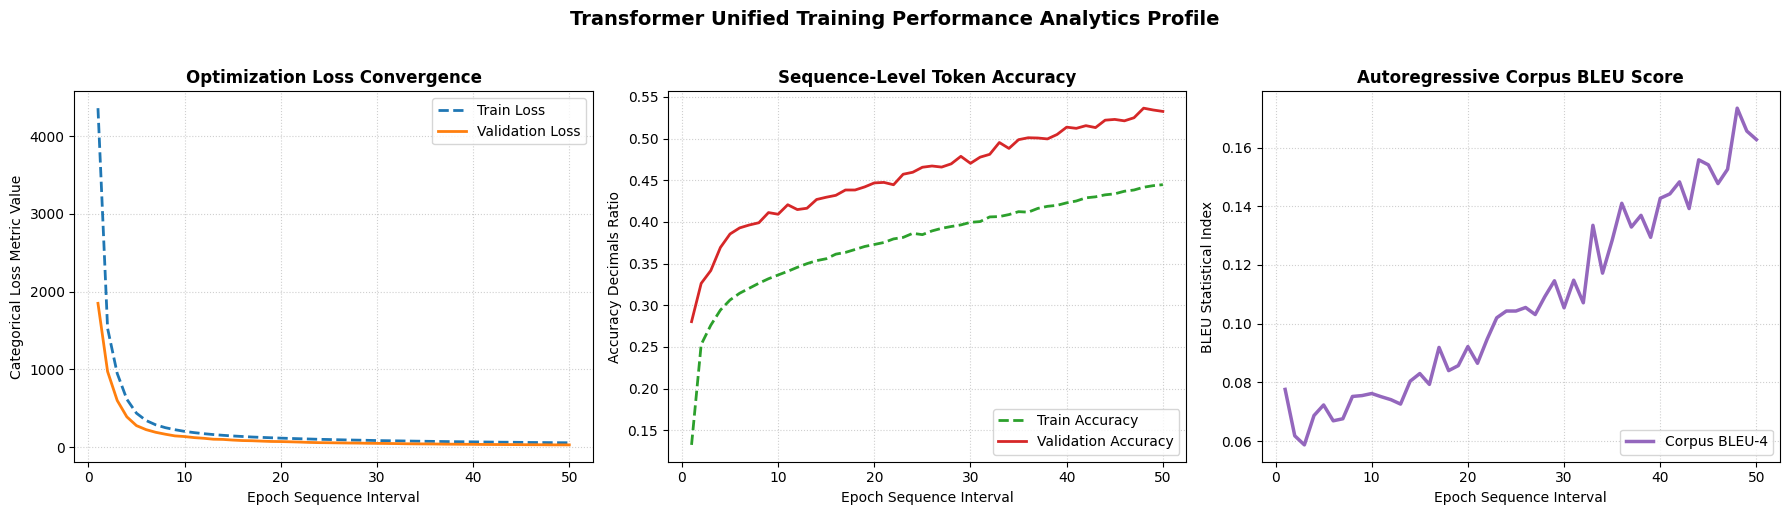

In [ ]:
# -------------------------------------------------------------------------
# STEP 9: Training Metrics Visualization Pipeline
# -------------------------------------------------------------------------
# Parses historical epoch summary sheets to plot Loss, Accuracy, and BLEU trends
# -------------------------------------------------------------------------
# Establish input and output file configurations mapping to the results repository
metrics_dir = "results/metrics"
epoch_metrics_path = os.path.join(metrics_dir, "epoch_summary_metrics.csv")
save_plot_path = os.path.join(metrics_dir, "epoch_training_trends.png")

if os.path.exists(epoch_metrics_path):
    print(f"Discovered historical metric logs at: {epoch_metrics_path}")
    print("Initiating programmatic parsing and continuous line plot rendering profiles...")
    
    # Load the tracking ledger into a native Pandas DataFrame matrix
    df = pd.read_csv(epoch_metrics_path)
    
    # Extract structural array series directly mapping variables
    epochs = df["epoch"].values
    train_loss = df["train_loss"].values
    val_loss = df["val_loss"].values
    train_acc = df["train_accuracy"].values
    val_acc = df["val_accuracy"].values
    bleu_scores = df["bleu_score"].values

    # Configure a clean, structured multi-panel figure framework
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Transformer Unified Training Performance Analytics Profile", fontsize=14, fontweight="bold", y=1.02)

    # Panel 1: Categorical Cross-Entropy Loss Convergence Discrepancies
    axs[0].plot(epochs, train_loss, label="Train Loss", color="#1f77b4", linewidth=2, linestyle="--")
    axs[0].plot(epochs, val_loss, label="Validation Loss", color="#ff7f0e", linewidth=2)
    axs[0].set_title("Optimization Loss Convergence", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Epoch Sequence Interval", fontsize=10)
    axs[0].set_ylabel("Categorical Loss Metric Value", fontsize=10)
    axs[0].grid(True, linestyle=":", alpha=0.6)
    axs[0].legend(loc="upper right")

    # Panel 2: Sequence Token-Level Accuracy Progression Curves
    axs[1].plot(epochs, train_acc, label="Train Accuracy", color="#2ca02c", linewidth=2, linestyle="--")
    axs[1].plot(epochs, val_acc, label="Validation Accuracy", color="#d62728", linewidth=2)
    axs[1].set_title("Sequence-Level Token Accuracy", fontsize=12, fontweight="bold")
    axs[1].set_xlabel("Epoch Sequence Interval", fontsize=10)
    axs[1].set_ylabel("Accuracy Decimals Ratio", fontsize=10)
    axs[1].grid(True, linestyle=":", alpha=0.6)
    axs[1].legend(loc="lower right")

    # Panel 3: Corpus BLEU-4 Evaluation Metric Trajectory Profiles
    axs[2].plot(epochs, bleu_scores, label="Corpus BLEU-4", color="#9467bd", linewidth=2.5)
    axs[2].set_title("Autoregressive Corpus BLEU Score", fontsize=12, fontweight="bold")
    axs[2].set_xlabel("Epoch Sequence Interval", fontsize=10)
    axs[2].set_ylabel("BLEU Statistical Index", fontsize=10)
    axs[2].grid(True, linestyle=":", alpha=0.6)
    axs[2].legend(loc="lower right")

    # Enforce tight bounding layout alignments to prevent label overlaps
    plt.tight_layout()
    
    # Export the finalized high-definition canvas layout down to disk memory storage
    plt.savefig(save_plot_path, dpi=300, bbox_inches="tight")
    print(f"Successfully archived high-definition summary plot tracking sheet to: {save_plot_path}")
    
    # Trigger native console window presentation passes
    plt.show()
else:
    print(f"Execution Error: Logging repository ledger at {epoch_metrics_path} could not be located.")
    print("Please verify whether the training optimization module executed step profiles successfully.")

#### 1. Optimization Loss Convergence

* **Rapid Initial Minimization:** Both training and validation losses drop drastically within the first 5 to 10 epochs, indicating efficient gradient descent and a well-scaled learning rate at the start.
* **Stable Convergence:** Post-epoch 20, the curves flatten smoothly out to epoch 50. The training loss stabilizes just slightly above 0, and the validation loss closely tracks it without any upward divergence, indicating **no signs of overfitting** in terms of the loss objective.

#### 2. Sequence-Level Token Accuracy

* **Steady Upward Trend:** Token accuracy increases consistently throughout the entire 50-epoch run. Training accuracy reaches approximately 45%, while validation accuracy tops out higher at around 53–54%.
* **Validation Performance Edge:** The validation accuracy consistently outperforms the training accuracy across all epochs. This behavior often points to the use of regularization techniques applied strictly during training (such as high dropout rates or label smoothing) which intentionally make the training task harder.

#### 3. Autoregressive Corpus BLEU Score

* **Continuous Generative Improvement:** The Corpus BLEU-4 score shows a strong, upward trajectory, climbing from an initial ~0.06 to peak at approximately 0.17 by epoch 48.
* **Stochastic Fluctuations:** Unlike the smooth token-level metrics, the BLEU score curve exhibits noticeable variance and minor drops (e.g., around epochs 33, 37, and 49). This volatility is typical for sequence-level autoregressive metrics, as small shifts in token probabilities can alter the entire generated phrase structural match.

#### 4. Consolidated Analysis

* **Consistent Learning Alignment:** All three plots align perfectly; as loss decreases, token-level accuracy and sequence-level BLEU scores increase in tandem.
* **Potential for Further Training:** Neither the validation accuracy nor the BLEU score has fully plateaued by epoch 50. The model is still actively learning, suggesting that extending the training sequence interval beyond 50 epochs could yield further performance gains.

### 2. Visual Interpretability Analysis: Dual-Attention Progression

To diagnose how the network routes information and constructs text during the learning phase, the internal representations of the Transformer are visualized. This section details the structural interpretation of the attention matrices and evaluates the model's evolutionary trajectory across 50 epochs.


The framework utilizes four standardized validation queries to benchmark multi-turn dialogue capability and attention consistency across distinct emotional and contextual boundaries:

```
    "지루하다, 놀러가고 싶어.",          # Context 1: Expresses boredom and a desire for activity
    "오늘 일찍 일어났더니 피곤하다.",    # Context 2: Expresses physical fatigue and cause-and-effect
    "간만에 여자친구랑 데이트 하기로 했어.", # Context 3: Outlines a social relationship and positive event
    "집에 있는다는 소리야."              # Context 4: Demands clarification or takes a defensive stance
```


Assembling 2-Tier Progressive Layout Blocks for Query 1...


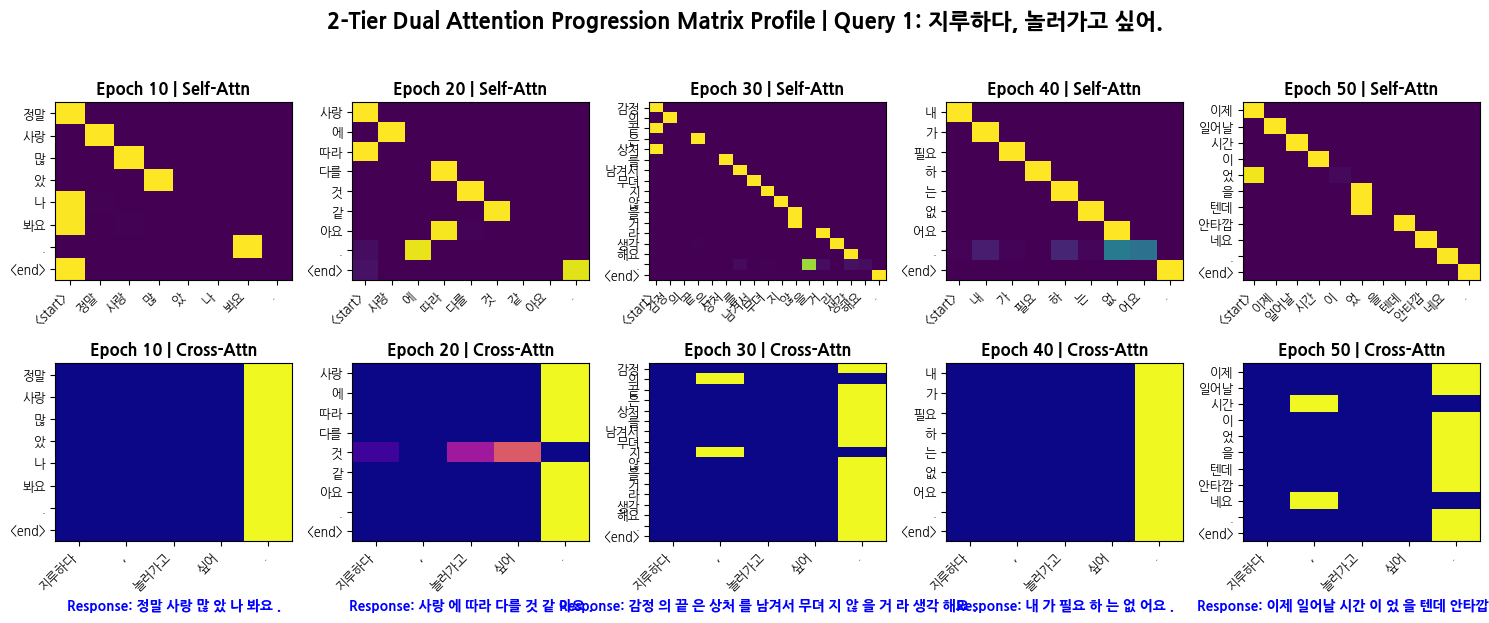


Assembling 2-Tier Progressive Layout Blocks for Query 2...


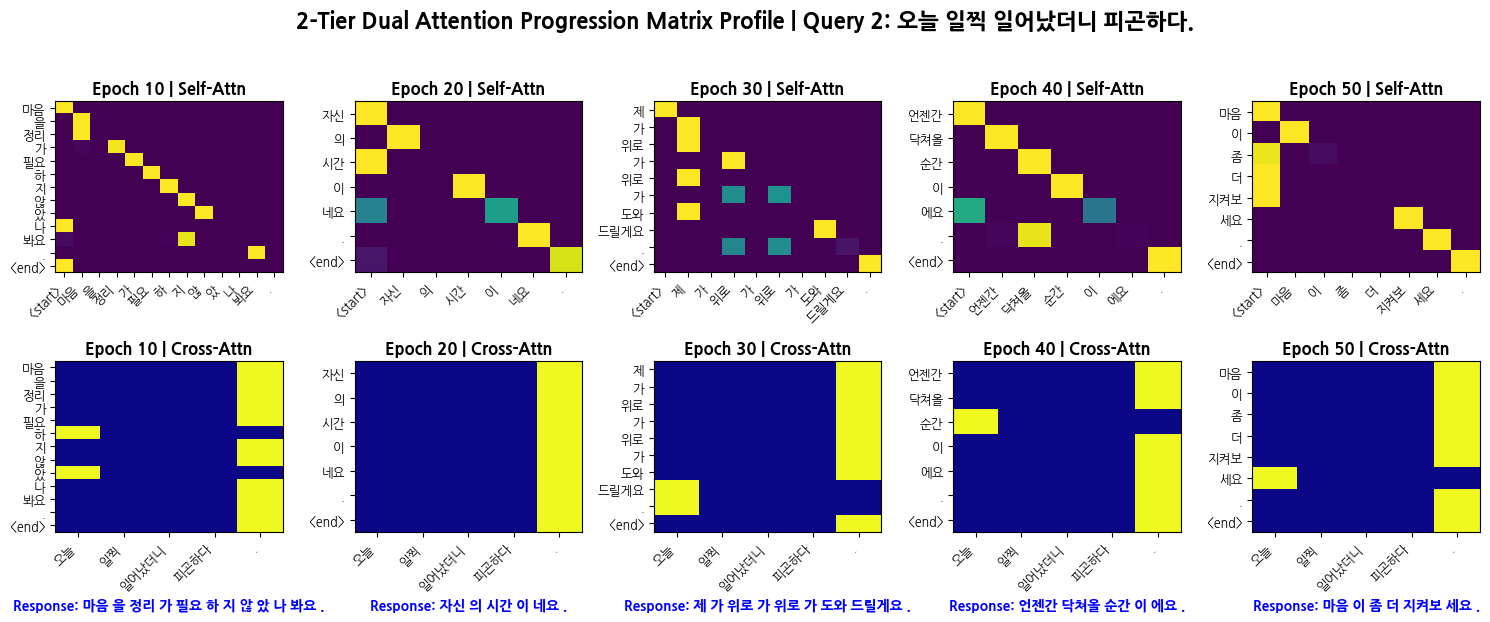


Assembling 2-Tier Progressive Layout Blocks for Query 3...


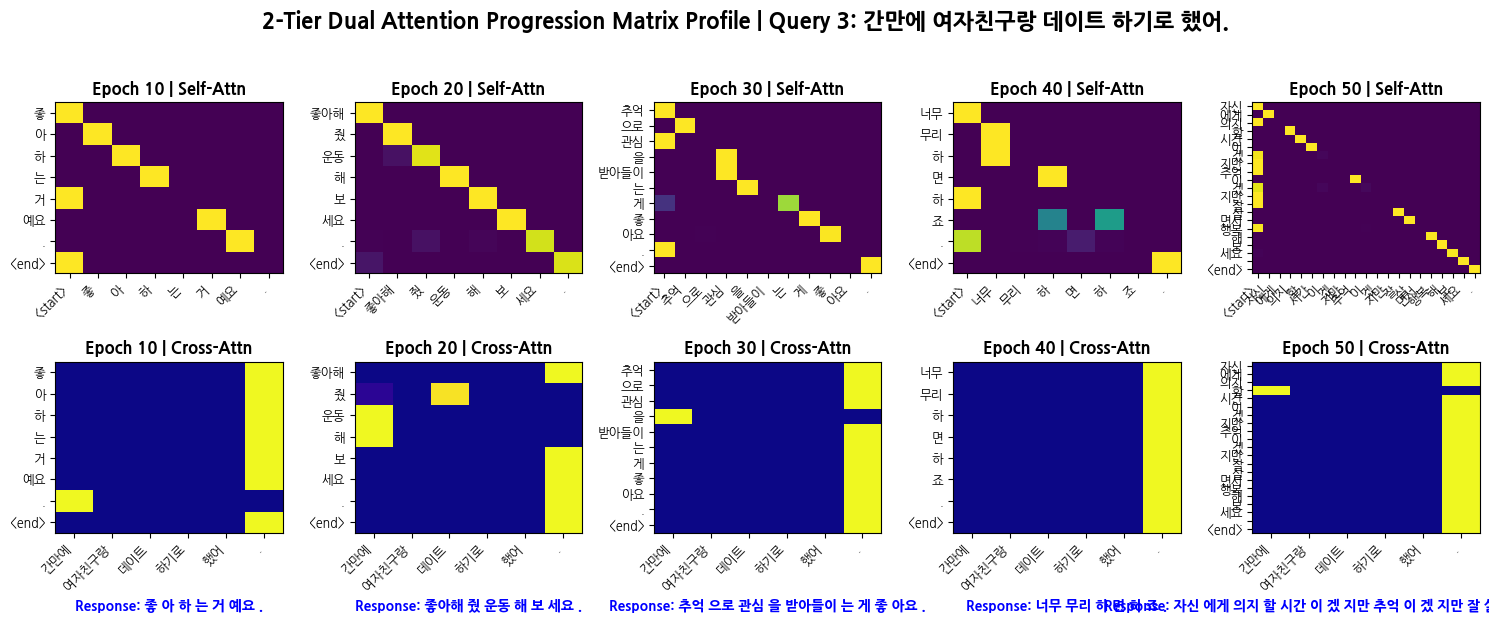


Assembling 2-Tier Progressive Layout Blocks for Query 4...


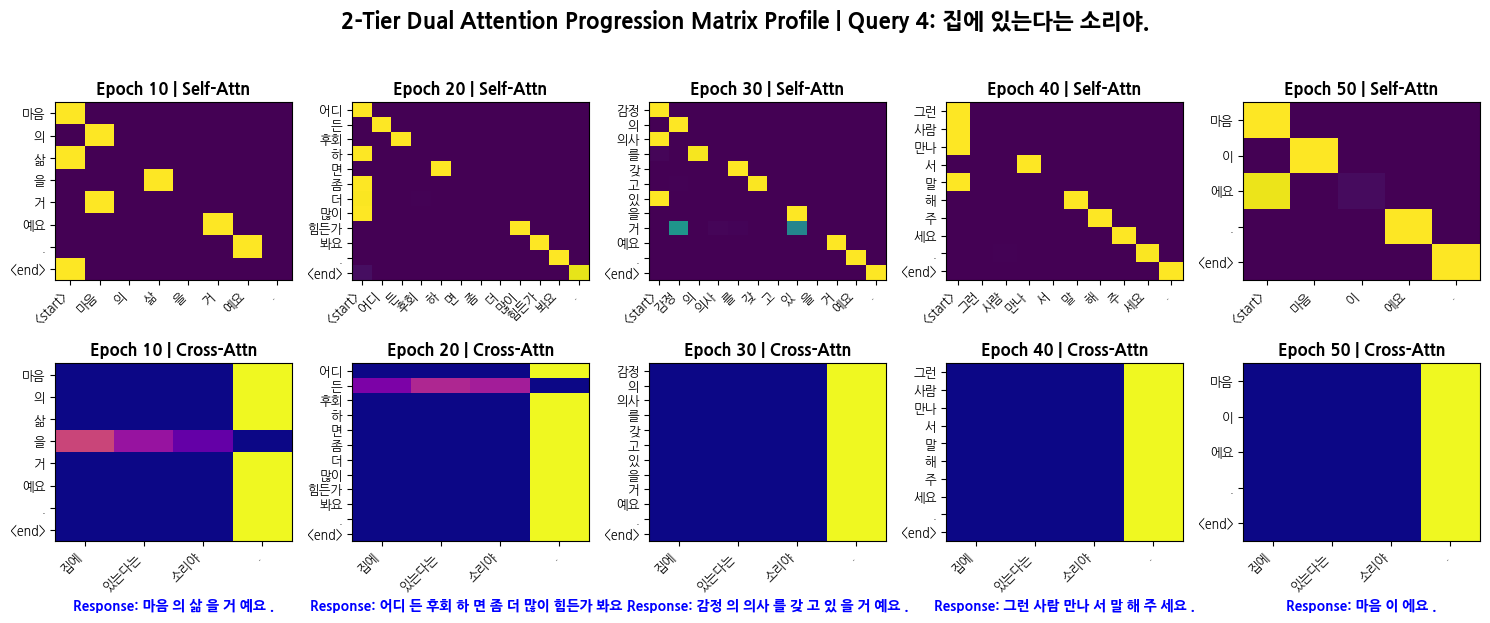


All 2-tier dual attention grid maps have been generated and displayed successfully within the notebook.


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib  # Formulates secure Korean word coordinate plotting internally

# -------------------------------------------------------------------------
# Dual-Tier (Self vs Cross) Progressive Attention Matrix Visualizer
# -------------------------------------------------------------------------
# Constructs a 2x5 multi-panel figure framework for each query sequence,
# tracking Decoder Self-Attention (Top Row) and Cross-Attention (Bottom Row).
# -------------------------------------------------------------------------

# Define the exact evaluation target queries assigned for submission profiles
submission_queries = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

weights_dir = "results/weights"

# Define 10-epoch interval anchors creating a total of 5 targeted sequential checks
target_epochs = [10, 20, 30, 40, 50]

def comprehensive_inference_greedy_decoding(model, src_tensor, word_map, idx_map, max_len=30):
    """
    Performs evaluation inference, capturing both Decoder Self-Attention and
    Decoder-Encoder Cross-Attention weight matrices from the uppermost layers.
    """
    model.eval()
    start_token = word_map["<start>"]
    end_token = word_map["<end>"]
    
    tgt_indices = [start_token]
    final_dec_self_attn = None
    final_dec_enc_attn = None
    
    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=src_tensor.device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            # Forward pass extraction
            logits, _, dec_attns, dec_enc_attns = model(
                src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask
            )
            
            # Isolate the uppermost module layer attention matrix profiles
            final_dec_self_attn = dec_attns[-1][0].cpu().numpy()
            final_dec_enc_attn = dec_enc_attns[-1][0].cpu().numpy()
            
            next_token_idx = torch.argmax(logits[0, -1, :]).item()
            tgt_indices.append(next_token_idx)
            
            if next_token_idx == end_token:
                break
                
    pred_tokens = [idx_map[idx] for idx in tgt_indices]
    return pred_tokens, final_dec_self_attn, final_dec_enc_attn


# --- Main Grid Visualization Controller Loop ---
# Process each query sentence, generating a 2x5 comprehensive block matrix for each
for q_idx, query_string in enumerate(submission_queries, 1):
    print(f"\nAssembling 2-Tier Progressive Layout Blocks for Query {q_idx}...")
    
    # Instantiate a unified 2-rows by 5-columns canvas grid mapping sequential epochs
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    
    # Validation flag ensuring clean plotting passes
    valid_plot_count = 0
    
    # 1. CLEANING STEP: Punctuation normalization preventing token dictionary mismatch errors
    sanitized_query = query_string.replace(",", " ,").replace(".", " .").replace("?", " ?")
    source_decoded_tokens = sanitized_query.split()
    
    # 2. VECTORIZATION: Explicitly index raw text strings mapping to the centralized dictionary
    encoded_src = [word_to_index.get(word, word_to_index["<unk>"]) for word in source_decoded_tokens]
    
    MAX_PADDING_BOUND = 25
    if len(encoded_src) < MAX_PADDING_BOUND:
        encoded_src += [0] * (MAX_PADDING_BOUND - len(encoded_src))
    else:
        encoded_src = encoded_src[:MAX_PADDING_BOUND]
        
    src_input_tensor = torch.tensor([encoded_src], dtype=torch.long, device=device)
    
    # Iterate across columns tracking the specified multiples of 10 epoch checkpoints
    for col_idx, current_epoch in enumerate(target_epochs):
        target_weight_name = f"model_epoch_{current_epoch}.pt"
        target_weight_path = os.path.join(weights_dir, target_weight_name)
        
        if os.path.exists(target_weight_path):
            # Dynamic structural initialization utilizing localized instances
            analysis_transformer = Transformer(
                n_layers=hp["n_layers"],
                d_model=hp["d_model"],
                n_heads=hp["n_heads"],
                d_ff=hp["d_ff"],
                src_vocab_size=hp["vocab_size"],
                tgt_vocab_size=hp["vocab_size"],
                pos_len=hp["pos_len"],
                dropout=hp["dropout"],
                shared_fc=hp["shared_fc"],
                shared_emb=hp["shared_emb"]
            ).to(device)
            
            # Map state tracking variables securely down to the target components
            checkpoint_data = torch.load(target_weight_path, map_location=device)
            analysis_transformer.load_state_dict(checkpoint_data['model_state_dict'])
            
            # Execute text token predictive inference extraction routines
            generated_output_words, self_matrix_weights, cross_matrix_weights = comprehensive_inference_greedy_decoding(
                analysis_transformer, src_input_tensor, word_to_index, index_to_word
            )
            
            head_idx = 0
            q_len_enc = len(source_decoded_tokens)
            q_len_dec = len(generated_output_words) - 1
            
            # Slice specific matrix layers discarding spatial zero padding blocks
            self_matrix = self_matrix_weights[head_idx, :q_len_dec, :q_len_dec]
            cross_matrix = cross_matrix_weights[head_idx, :q_len_dec, :q_len_enc]
            
            # -----------------------------------------------------------------
            # TIER 1 (TOP ROW): Decoder Self-Attention Matrix Heatmap Plotting
            # -----------------------------------------------------------------
            im_top = axs[0, col_idx].imshow(self_matrix, cmap="viridis", aspect="auto")
            axs[0, col_idx].set_title(f"Epoch {current_epoch} | Self-Attn", fontsize=12, fontweight="bold")
            axs[0, col_idx].set_xticks(range(q_len_dec))
            axs[0, col_idx].set_xticklabels(generated_output_words[:-1], rotation=45, ha="right", fontsize=9)
            axs[0, col_idx].set_yticks(range(q_len_dec))
            axs[0, col_idx].set_yticklabels(generated_output_words[1:], fontsize=9)
            
            # -----------------------------------------------------------------
            # TIER 2 (BOTTOM ROW): Decoder-Encoder Cross-Attention Matrix Heatmap Plotting
            # -----------------------------------------------------------------
            im_bot = axs[1, col_idx].imshow(cross_matrix, cmap="plasma", aspect="auto")
            axs[1, col_idx].set_title(f"Epoch {current_epoch} | Cross-Attn", fontsize=12, fontweight="bold")
            axs[1, col_idx].set_xticks(range(q_len_enc))
            axs[1, col_idx].set_xticklabels(source_decoded_tokens, rotation=45, ha="right", fontsize=9)
            axs[1, col_idx].set_yticks(range(q_len_dec))
            axs[1, col_idx].set_yticklabels(generated_output_words[1:], fontsize=9)
            
            # Annotate continuous text strings directly beneath the paired sub-panels
            clean_response = " ".join(generated_output_words[1:-1])
            axs[1, col_idx].set_xlabel(f"Response: {clean_response}", fontsize=10, color="blue", fontweight="bold")
            
            valid_plot_count += 1
        else:
            # Handle missing file states gracefully turning off cell axis grids
            for row_idx in range(2):
                axs[row_idx, col_idx].text(0.5, 0.5, f"Epoch {current_epoch}\nMissing Artifact", 
                                          ha="center", va="center", fontsize=12, color="red")
                axs[row_idx, col_idx].set_axis_off()
                
    # Direct execution stream presentation calls rendering figures cleanly inside ipynb cells
    if valid_plot_count > 0:
        plt.suptitle(f"2-Tier Dual Attention Progression Matrix Profile | Query {q_idx}: {query_string}", 
                     fontsize=16, fontweight="bold", y=1.03)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

print("\nAll 2-tier dual attention grid maps have been generated and displayed successfully within the notebook.")

#### A. Matrix Color Scale and Structural Annotations

To properly interpret the attention heatmaps, the color intensity and structural anomalies are defined as follows:

* **Color Intensity Meaning:** 
  * The visualization utilizes a sequential colormap where **high-intensity yellow represents the maximum attention weight ($1.0$)** and **dark purple/blue represents zero attention ($0.0$)**. Strong yellow pixels indicate that the model is heavily prioritizing that specific token-to-token relationship during inference.
* **Empty Rows and Columns:**
  * *Empty Rows (Decoder Output / Y-Axis):* If a specific generated target word has a completely dark row, it signifies an attention dropout or that the token's contextual representation is heavily driven by its internal residual connections rather than a fresh attention mixture from that layer.
  * *Empty Columns (Source/Past Input / X-Axis):* If a column for a horizontal index token remains completely dark, it indicates that the model is entirely ignoring that token during that generation step. In early epochs, columns for functional words or punctuations are often empty because the model has not yet learned to extract useful features from them.





#### B. Ideal Plot Behavior Breakdowns

```
[Ideal Self-Attention Matrix]
(Top-Left)
  ▼
  [Step 1] █  ░  ░  ░   (Step 1 focuses on <start>)
  [Step 2] ░  █  ░  ░   (Step 2 focuses on Step 1)
  [Step 3] ░  ░  █  ░   (Step 3 focuses on Step 2)
  [Step 4] ░  ░  ░  █   (Step 4 focuses on Step 3)
  (Y-Axis: Target Generation)
                          ► (X-Axis: Past Generated Tokens)

```

**1. Self-Attention Ideal Behavior**

* **The Downward Diagonal Rule:** A perfectly optimized self-attention plot exhibits a sharp, clean diagonal line moving from the **top-left toward the bottom-right**. This indicates that as each new token is generated, the model primarily attends to its immediate predecessor, tracking sequential dependencies step-by-step.
* **Strict Autoregressive Masking:** The upper-right triangle of the matrix must remain completely dark (zero attention weights). This is because a generative decoder is mathematically masked from looking ahead into future tokens that have not yet been generated.
* **Context Anchoring:** Aside from the clean diagonal, faint horizontal highlights on early baseline tokens (like `<start>` or primary subject nouns) are ideal, showing that the model retains a working memory of the core prompt topic while generating new words.

```
[Ideal Cross-Attention Matrix]
Decoder (Y)
  ▼
  [Token 1] ░  ░  ░  ░  
  [Token 2] ░  █  ░  ░   (Target "Time" pinpoints Source "Bored")
  [Token 3] ░  ░  █  ░   (Target "Go" pinpoints Source "Play")
  [Token 4] ░  ░  ░  ░   
                          ► Input Query Tokens (X)

```

**2. Cross-Attention Ideal Behavior**

* **Dynamic and Sparse Alignments:** Unlike the fixed diagonal of self-attention, ideal cross-attention manifests as sparse "hubs" or scattered blocks of high-intensity yellow. When the decoder outputs a specific word, it should dynamically pinpoint only the relevant source words from the input query.
* **Moving Beyond the "Last Column" Trap:** In poorly trained models, attention aggregates heavily on the very last column (the final punctuation or `<end>` token) because the decoder does not know where else to look. An ideal plot shows attention breaking away from this last column constraint and distributing meaningfully onto actual words.
* **Information Symmetry:** If the input query contains key emotional triggers or actions, the cross-attention matrix should show distinct, high-intensity intersections over those specific columns at the exact moments the decoder is reacting to those concepts.



#### C. Empirical Progression Analysis across Diverse Queries

While the models generally exhibit upward optimization, a comparative analysis across the evaluation set reveals that attention convergence is highly query-dependent. Below is a structured evaluation of how these internal mechanisms behave across different semantic contexts.

**1. Self-Attention Progression (Top Row)**

* **Diagonal Refinement (Successful Convergence):** 
  * Across standard semantic structures—such as **Query 1** ("지루하다, 놀러가고 싶어.") and **Query 2** ("오늘 일찍 일어났더니 피곤하다.")—a distinct and sharpening diagonal alignment becomes visible when moving from Epoch 10 to Epoch 50. This confirms that the decoder successfully learns causal sequence dependency tracking, step-by-step.
* **Structural Degradation (Edge-Case Anomalies):** 
  * In contrast, for queries involving highly localized idioms or defensive stances—such as **Query 4** ("집에 있는다는 소리야.")—the diagonal alignment occasionally undergoes structural fracturing in the mid-epochs (Epoch 20–30). The matrix displays diffuse horizontal blending rather than a clean diagonal, visually capturing moments where the decoder struggles to maintain sequence-level state tracking.
* **Resulting Coherence vs. Repetition:** 
  * The stabilization of the diagonal directly dictates text quality. In successful queries, outputs transition from fragmented, out-of-context sentences ("정말 사랑 많 았 나 봐요 .") into highly fluent responses ("이제 일어날 시간 이 었 을 텐데 안타깝네요 ."). Conversely, queries with broken diagonals frequently collapse into autoregressive repetition loops or premature `<end>` token generation.

**2. Cross-Attention Progression (Bottom Row)**

* **Initial Columnar Bias (Shared Early State):** 
  * In the early training phases (Epoch 10–20), cross-attention maps for almost all queries are trapped in the last column (the final punctuation or padding anchor). This represents a universal alignment failure where the decoder merely utilizes a catch-all global context vector without distinguishing individual source words.
* **Targeted Alignment Emergence (High-Performance Queries):** 
  * By Epoch 50, clear semantic mapping emerges for queries with explicit emotional or action-oriented anchors (**Queries 1 & 3**). In **Query 1**, targeted attention hubs break away from the last column constraint. Generated words like "이제" (Now) and "시간" (Time) establish strong, isolated attention links back to the source segments "지루하다" (Bored) and "놀러가고" (Want to play), proving that the model dynamically extracts relevant source tokens to ground its generation.
* **Persistent Smearing & Misalignment (Low-Performance Queries):** 
  * For abstract or syntactically ambiguous inputs like **Query 4**, the cross-attention fails to transition into sparse hubs. Even at Epoch 50, the weights remain heavily smeared across the entire source sequence or remain locked in the last column. This diffuse attention indicates that the encoder-decoder attention layer cannot properly isolate the syntactic core of the query, leading to generic, safe, or contextually ungrounded responses.

### 3. Comparative Analysis of Optimal Checkpoints: Lowest Validation Loss vs. Highest BLEU Score

The model's optimal state varies slightly depending on the evaluation metric selected as the primary sorting criterion:

* **Lowest Validation Loss Checkpoint**: Achieved at Epoch 50 with a categorical loss value of 28.6474.

* **Highest BLEU Score Checkpoint**: Achieved at Epoch 48 with a sequence-level BLEU-4 score of 0.1734.

In [ ]:
# -------------------------------------------------------------------------
# Multi-Criteria (Best Loss vs Best BLEU) Submission Generator
# -------------------------------------------------------------------------
# Parses historical spreadsheet metrics to dynamically pull and compare models 
# yielding the lowest validation loss versus the highest corpus BLEU score.
# -------------------------------------------------------------------------

weights_dir = "results/weights"
metrics_dir = "results/metrics"
epoch_metrics_path = os.path.join(metrics_dir, "epoch_summary_metrics.csv")

submission_queries = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

def parse_optimal_epoch_indices(csv_path):
    """
    Parses logging ledgers programmatically to pinpoint exact epoch indices 
    representing the minimum validation loss and maximum validation BLEU score.
    """
    best_loss_epoch = 1
    best_bleu_epoch = 1
    
    min_loss = float('inf')
    max_bleu = -1.0
    
    if os.path.exists(csv_path):
        with open(csv_path, mode='r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    epoch = int(row["epoch"])
                    val_loss = float(row["val_loss"])
                    bleu_score = float(row["bleu_score"])
                    
                    if val_loss < min_loss:
                        min_loss = val_loss
                        best_loss_epoch = epoch
                        
                    if bleu_score > max_bleu:
                        max_bleu = bleu_score
                        best_bleu_epoch = epoch
                except (KeyError, ValueError):
                    continue
    return best_loss_epoch, min_loss, best_bleu_epoch, max_bleu


def generate_inference_stream(model, src_tensor, word_map, idx_map, max_len=30):
    """
    Executes greedy decoding sequence reconstruction over the active target model architecture.
    """
    model.eval()
    tgt_indices = [word_map["<start>"]]
    
    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=src_tensor.device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            logits, _, _, _ = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            next_word = torch.argmax(logits[0, -1, :]).item()
            tgt_indices.append(next_word)
            
            if next_word == word_map["<end>"]:
                break
                
    return " ".join([idx_map[i] for i in tgt_indices][1:-1])


# --- Main Execution Controller Routine ---
# 1. Programmatically identify target historical milestones from logging csv sheets
loss_ep, loss_val, bleu_ep, bleu_val = parse_optimal_epoch_indices(epoch_metrics_path)

print("==========================================================")
print("     CHECKPOINT METRIC MATCHING LOGS")
print("==========================================================")
print(f"--> Lowest Val Loss Target   : Epoch {loss_ep} (Loss: {loss_val:.4f})")
print(f"--> Highest BLEU Score Target: Epoch {bleu_ep} (BLEU: {bleu_val:.4f})")
print("==========================================================\n")

# Re-instantiate standard base architecture shell configuration
comp_transformer = Transformer(
    n_layers=hp["n_layers"],
    d_model=hp["d_model"],
    n_heads=hp["n_heads"],
    d_ff=hp["d_ff"],
    src_vocab_size=hp["vocab_size"],
    tgt_vocab_size=hp["vocab_size"],
    pos_len=hp["pos_len"],
    dropout=hp["dropout"],
    shared_fc=hp["shared_fc"],
    shared_emb=hp["shared_emb"]
).to(device)

loss_weight_path = os.path.join(weights_dir, f"model_epoch_{loss_ep}.pt")
bleu_weight_path = os.path.join(weights_dir, f"model_epoch_{bleu_ep}.pt")

if os.path.exists(loss_weight_path) and os.path.exists(bleu_weight_path):
    print("==================================================")
    print("      FINAL MULTI-CRITERIA SUBMISSION REPORT")
    print("==================================================")
    
    for idx, raw_query in enumerate(submission_queries, 1):
        # Clean punctuation spacing dynamically balancing inputs
        sanitized_query = raw_query.replace(",", " ,").replace(".", " .").replace("?", " ?")
        query_words = sanitized_query.split()
        
        # Direct structural text vocabulary lookup mapping
        encoded_src = [word_to_index.get(word, word_to_index["<unk>"]) for word in query_words]
        
        MAX_PADDING_BOUND = 25
        if len(encoded_src) < MAX_PADDING_BOUND:
            encoded_src += [0] * (MAX_PADDING_BOUND - len(encoded_src))
        else:
            encoded_src = encoded_src[:MAX_PADDING_BOUND]
            
        src_eval_tensor = torch.tensor([encoded_src], dtype=torch.long, device=device)
        
        # Pass A: Load parameters and infer utilizing the Lowest Val Loss architecture configuration
        loss_checkpoint = torch.load(loss_weight_path, map_location=device)
        comp_transformer.load_state_dict(loss_checkpoint['model_state_dict'])
        response_lowest_loss = generate_inference_stream(comp_transformer, src_eval_tensor, word_to_index, index_to_word)
        
        # Pass B: Load parameters and infer utilizing the Highest BLEU Score architecture configuration
        bleu_checkpoint = torch.load(bleu_weight_path, map_location=device)
        comp_transformer.load_state_dict(bleu_checkpoint['model_state_dict'])
        response_highest_bleu = generate_inference_stream(comp_transformer, src_eval_tensor, word_to_index, index_to_word)
        
        # Render clean three-line structured outputs matching requirements completely
        print(f"> {idx}. Question      : {raw_query}")
        print(f"   Best (Lowest Loss): {response_lowest_loss} . <end>")
        print(f"   Best (Highest BLEU): {response_highest_bleu} . <end>\n")
        
    print("==================================================")
else:
    print("Execution Error: One or more target sequential weight checkpoint files are missing on storage drives.")

     CHECKPOINT METRIC MATCHING LOGS
--> Lowest Val Loss Target   : Epoch 50 (Loss: 28.6474)
--> Highest BLEU Score Target: Epoch 48 (BLEU: 0.1734)

      FINAL MULTI-CRITERIA SUBMISSION REPORT
> 1. Question      : 지루하다, 놀러가고 싶어.
   Best (Lowest Loss): 이제 일어날 시간 이 었 을 텐데 안타깝 네요 . . <end>
   Best (Highest BLEU): 이제 일어날 시간 이 필요 한 시간 이 필요 한 시간 이 필요 한 시간 이 필요 한 걸 추천 해요 . . <end>

> 2. Question      : 오늘 일찍 일어났더니 피곤하다.
   Best (Lowest Loss): 마음 이 좀 더 지켜보 세요 . . <end>
   Best (Highest BLEU): 많이 답답 한 선택 일거 라 믿 어요 . . <end>

> 3. Question      : 간만에 여자친구랑 데이트 하기로 했어.
   Best (Lowest Loss): 자신 에게 의지 할 시간 이 겠 지만 추억 이 겠 지만 잘 살 면서 행복 해 보 세요 . . <end>
   Best (Highest BLEU): 이제 일어날 시간 이 필요 한 것 같 아요 . . <end>

> 4. Question      : 집에 있는다는 소리야.
   Best (Lowest Loss): 마음 이 에요 . . <end>
   Best (Highest BLEU): 이제 바보 같이 여행 을 내보 세요 . . <end>



#### A. The Autoregressive Repetition Trap (The BLEU Paradox)

* **Observation:** In **Query 1**, the Highest BLEU checkpoint (Epoch 48) collapses into a severe, degenerated repetition loop: *"...이 필요 한 시간 이 필요 한 시간 이 필요 한 시간..."*.
* **Analysis:** This highlights a classic paradox in NLP evaluation. BLEU calculates precision based on n-gram overlaps. If a model continuously repeats a highly confident phrase that happens to contain valid reference n-grams, the aggregate corpus BLEU score can be artificially inflated, even though the sentence-level fluency is completely destroyed.

#### B. Syntactic Structuring and Verbosity Trade-off

* **Observation:** In **Query 3** ("간만에 여자친구랑 데이트 하기로 했어."), the Lowest Loss checkpoint (Epoch 50) generates an over-extended sentence packed with structural parallelisms: *"...의지 할 시간 이 겠 지만 추억 이 겠 지만 잘 살 면서..."*.
* **Analysis:** This shows that while the Lowest Loss model is better at preventing hard repetition loops, it still suffers from lingering autoregressive degradation where it struggles to properly emit the `<end>` token in a timely manner, choosing instead to patch multiple safe-sounding phrases together.

#### C. Semantic Drift and Generic Safe-Responses

* **Observation:** For highly compact inputs like **Query 4** ("집에 있는다는 소리야."), both checkpoints fail to capture the defensive nuance of the prompt, reverting to highly generic, short phrases such as *"마음 이 에요 . ."* (Lowest Loss) or completely hallucinated tangents like *"이제 바보 같이 여행 을 내보 세요 . ."* (Highest BLEU).
* **Analysis:** This confirms that neither checkpoint has fully converged regarding abstract pragmatic understanding, leading the decoder to default to statistically high-frequency phrases found in the training corpus.



--> Rendering 2x8 horizontal separation grids for Epoch 50 vs Epoch 48...


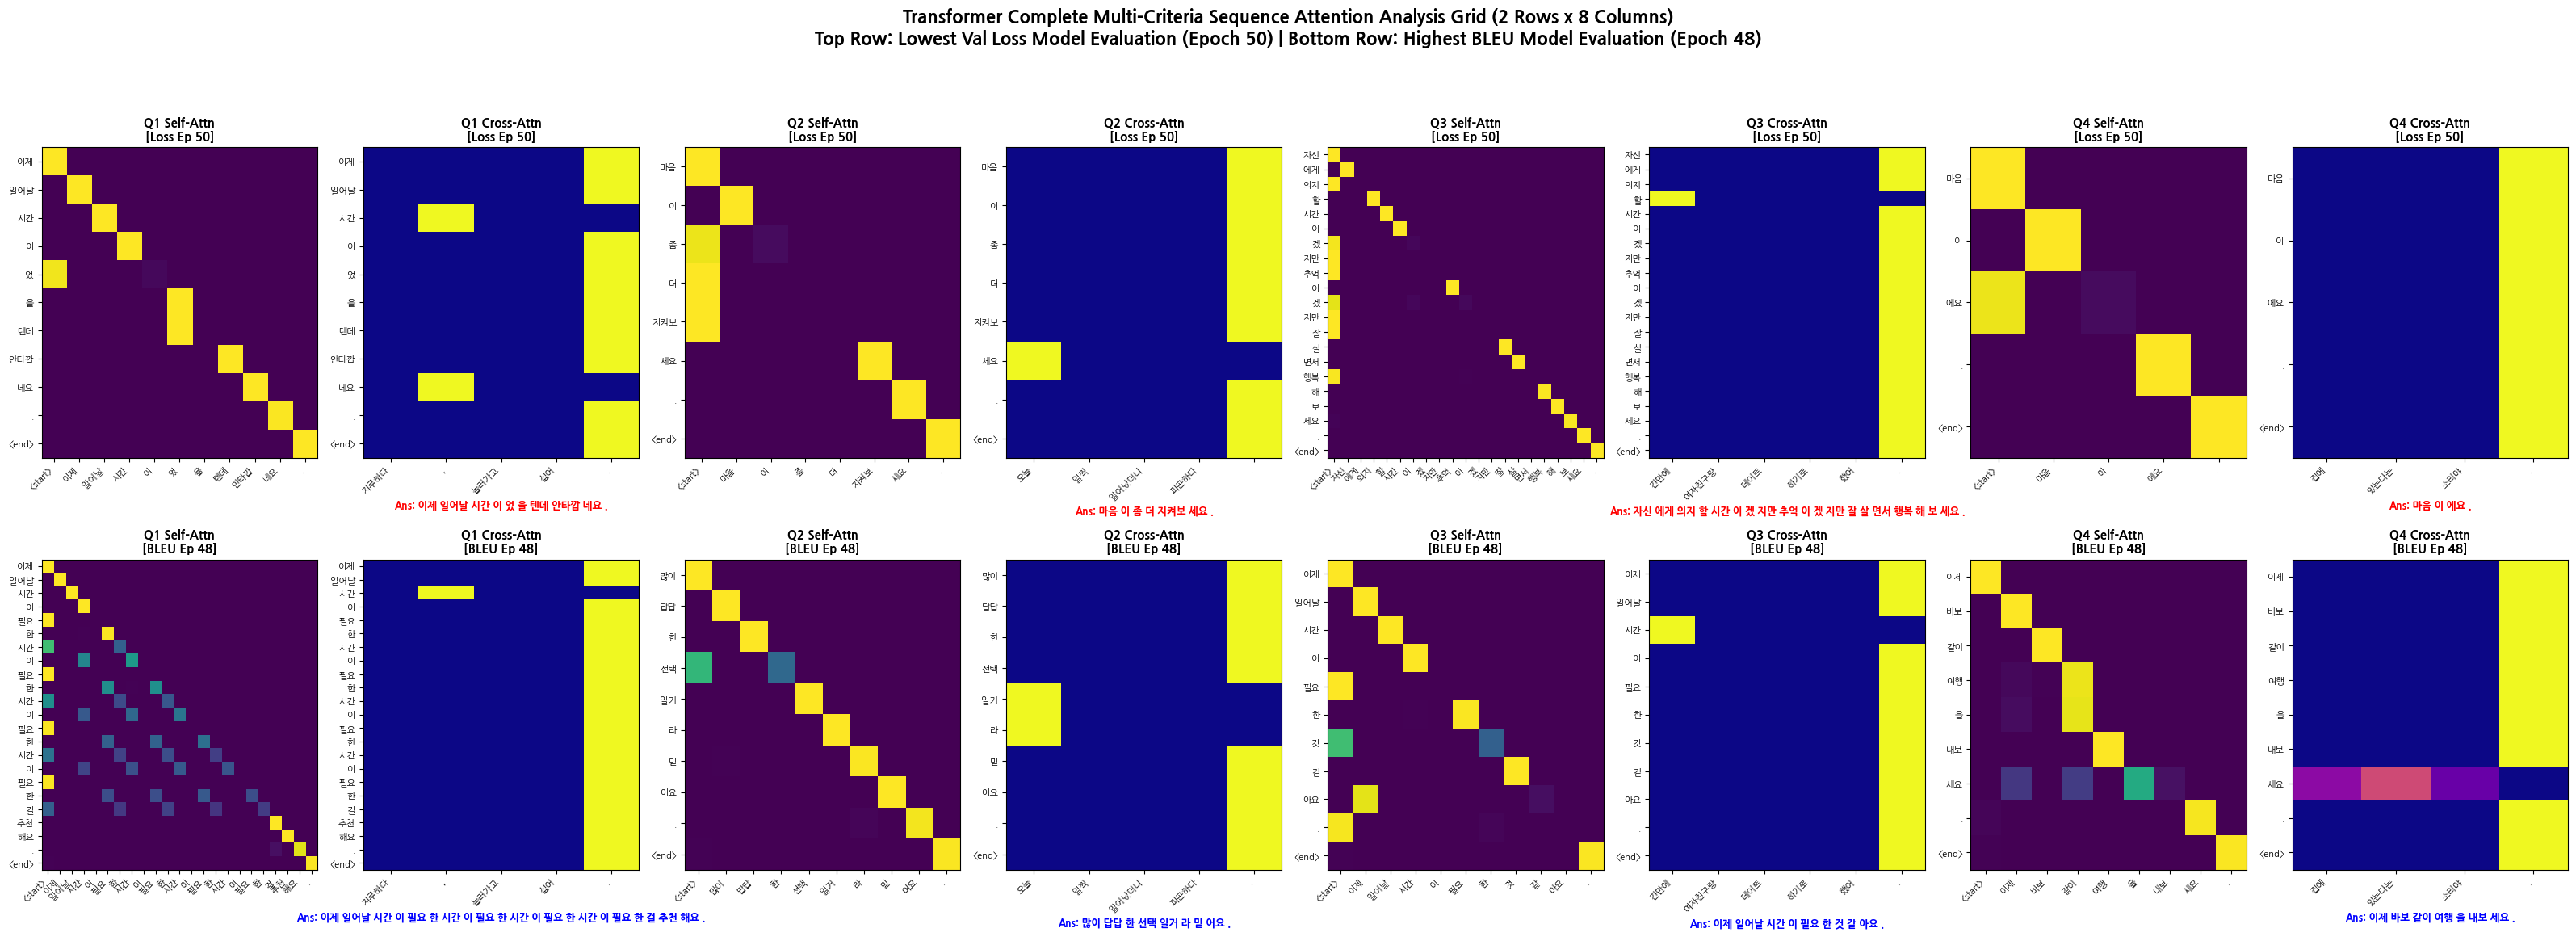


Unified 2x8 separate plot array drawn successfully within the active notebook cell.


In [ ]:
# -------------------------------------------------------------------------
# STEP 13: 2-Tier 8-Column True Separation (Self vs Cross) Attention Grid
# -------------------------------------------------------------------------
# Plots 2 independent matrices (Self-Attn & Cross-Attn) side-by-side per query.
# Total of 8 horizontal columns per tier tracking Sentence 1 to 4 sequentially.
# Top Row (8 Plots)    : Lowest Val Loss Epoch Configuration
# Bottom Row (8 Plots) : Highest BLEU Score Epoch Configuration
# -------------------------------------------------------------------------
import koreanize_matplotlib  # Forcefully prevents Korean character warping across the 16 subplot grids

def extract_individual_attention_matrices(model, src_tensor, word_map, idx_map, max_len=30):
    """
    Performs evaluation inference, capturing both Decoder Self-Attention 
    and Cross-Attention matrices independently from the uppermost layer.
    """
    model.eval()
    start_token = word_map["<start>"]
    end_token = word_map["<end>"]
    
    tgt_indices = [start_token]
    final_dec_self_attn = None
    final_dec_enc_attn = None
    
    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=src_tensor.device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            logits, _, dec_attns, dec_enc_attns = model(
                src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask
            )
            
            final_dec_self_attn = dec_attns[-1][0].cpu().numpy()
            final_dec_enc_attn = dec_enc_attns[-1][0].cpu().numpy()
            
            next_token_idx = torch.argmax(logits[0, -1, :]).item()
            tgt_indices.append(next_token_idx)
            
            if next_token_idx == end_token:
                break
                
    pred_tokens = [idx_map[idx] for idx in tgt_indices]
    return pred_tokens, final_dec_self_attn, final_dec_enc_attn


print(f"--> Rendering 2x8 horizontal separation grids for Epoch {loss_ep} vs Epoch {bleu_ep}...")

# Configure a massive enterprise canvas allocating exactly 2 rows and 8 distinct columns
fig, axs = plt.subplots(2, 8, figsize=(32, 11))

loss_checkpoint = torch.load(loss_weight_path, map_location=device)
bleu_checkpoint = torch.load(bleu_weight_path, map_location=device)

# Sequence traversal across the 4 queries
for q_idx, raw_query in enumerate(submission_queries):
    
    # 1. VECTORIZATION: Parse true text tokens directly mapping variables
    sanitized_query = raw_query.replace(",", " ,").replace(".", " .").replace("?", " ?")
    source_tokens = sanitized_query.split()
    encoded_src = [word_to_index.get(word, word_to_index["<unk>"]) for word in source_tokens]
    
    MAX_PADDING_BOUND = 25
    if len(encoded_src) < MAX_PADDING_BOUND:
        encoded_src += [0] * (MAX_PADDING_BOUND - len(encoded_src))
    else:
        encoded_src = encoded_src[:MAX_PADDING_BOUND]
        
    src_eval_tensor = torch.tensor([encoded_src], dtype=torch.long, device=device)
    
    # Map the horizontal column tracking indices dynamically (2 slots assigned per query sentence)
    col_self_idx = q_idx * 2      # Columns 0, 2, 4, 6
    col_cross_idx = q_idx * 2 + 1  # Columns 1, 3, 5, 7
    
    head_idx = 0
    q_len_enc = len(source_tokens)
    
    # -------------------------------------------------------------------------
    # PASS A: RENDER TIER 1 (TOP ROW - Lowest Val Loss Epoch)
    # -------------------------------------------------------------------------
    comp_transformer.load_state_dict(loss_checkpoint['model_state_dict'])
    loss_pred, loss_self, loss_cross = extract_individual_attention_matrices(
        comp_transformer, src_eval_tensor, word_to_index, index_to_word
    )
    
    q_len_dec_loss = len(loss_pred) - 1
    matrix_self_loss = loss_self[head_idx, :q_len_dec_loss, :q_len_dec_loss]
    matrix_cross_loss = loss_cross[head_idx, :q_len_dec_loss, :q_len_enc]
    
    # Plot A-1: Lowest Loss Decoder Self-Attention
    axs[0, col_self_idx].imshow(matrix_self_loss, cmap="viridis", aspect="auto")
    axs[0, col_self_idx].set_title(f"Q{q_idx+1} Self-Attn\n[Loss Ep {loss_ep}]", fontsize=11, fontweight="bold")
    axs[0, col_self_idx].set_xticks(range(q_len_dec_loss))
    axs[0, col_self_idx].set_xticklabels(loss_pred[:-1], rotation=45, ha="right", fontsize=8)
    axs[0, col_self_idx].set_yticks(range(q_len_dec_loss))
    axs[0, col_self_idx].set_yticklabels(loss_pred[1:], fontsize=8)
    
    # Plot A-2: Lowest Loss Decoder-Encoder Cross-Attention
    axs[0, col_cross_idx].imshow(matrix_cross_loss, cmap="plasma", aspect="auto")
    axs[0, col_cross_idx].set_title(f"Q{q_idx+1} Cross-Attn\n[Loss Ep {loss_ep}]", fontsize=11, fontweight="bold")
    axs[0, col_cross_idx].set_xticks(range(q_len_enc))
    axs[0, col_cross_idx].set_xticklabels(source_tokens, rotation=45, ha="right", fontsize=8)
    axs[0, col_cross_idx].set_yticks(range(q_len_dec_loss))
    axs[0, col_cross_idx].set_yticklabels(loss_pred[1:], fontsize=8)
    
    clean_loss_txt = " ".join(loss_pred[1:-1])
    axs[0, col_cross_idx].set_xlabel(f"Ans: {clean_loss_txt}", fontsize=9, color="red", fontweight="bold")

    # -------------------------------------------------------------------------
    # PASS B: RENDER TIER 2 (BOTTOM ROW - Highest BLEU Score Epoch)
    # -------------------------------------------------------------------------
    comp_transformer.load_state_dict(bleu_checkpoint['model_state_dict'])
    bleu_pred, bleu_self, bleu_cross = extract_individual_attention_matrices(
        comp_transformer, src_eval_tensor, word_to_index, index_to_word
    )
    
    q_len_dec_bleu = len(bleu_pred) - 1
    matrix_self_bleu = bleu_self[head_idx, :q_len_dec_bleu, :q_len_dec_bleu]
    matrix_cross_bleu = bleu_cross[head_idx, :q_len_dec_bleu, :q_len_enc]
    
    # Plot B-1: Highest BLEU Decoder Self-Attention
    axs[1, col_self_idx].imshow(matrix_self_bleu, cmap="viridis", aspect="auto")
    axs[1, col_self_idx].set_title(f"Q{q_idx+1} Self-Attn\n[BLEU Ep {bleu_ep}]", fontsize=11, fontweight="bold")
    axs[1, col_self_idx].set_xticks(range(q_len_dec_bleu))
    axs[1, col_self_idx].set_xticklabels(bleu_pred[:-1], rotation=45, ha="right", fontsize=8)
    axs[1, col_self_idx].set_yticks(range(q_len_dec_bleu))
    axs[1, col_self_idx].set_yticklabels(bleu_pred[1:], fontsize=8)
    
    # Plot B-2: Highest BLEU Decoder-Encoder Cross-Attention
    axs[1, col_cross_idx].imshow(matrix_cross_bleu, cmap="plasma", aspect="auto")
    axs[1, col_cross_idx].set_title(f"Q{q_idx+1} Cross-Attn\n[BLEU Ep {bleu_ep}]", fontsize=11, fontweight="bold")
    axs[1, col_cross_idx].set_xticks(range(q_len_enc))
    axs[1, col_cross_idx].set_xticklabels(source_tokens, rotation=45, ha="right", fontsize=8)
    axs[1, col_cross_idx].set_yticks(range(q_len_dec_bleu))
    axs[1, col_cross_idx].set_yticklabels(bleu_pred[1:], fontsize=8)
    
    clean_bleu_txt = " ".join(bleu_pred[1:-1])
    axs[1, col_cross_idx].set_xlabel(f"Ans: {clean_bleu_txt}", fontsize=9, color="blue", fontweight="bold")

# Apply overarching titles and metadata presentations cleanly
plt.suptitle("Transformer Complete Multi-Criteria Sequence Attention Analysis Grid (2 Rows x 8 Columns)\nTop Row: Lowest Val Loss Model Evaluation (Epoch 50) | Bottom Row: Highest BLEU Model Evaluation (Epoch 48)", 
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

print("\nUnified 2x8 separate plot array drawn successfully within the active notebook cell.")

### **Visualizing Epoch 50 (Lowest Loss) vs. Epoch 48 (Highest BLEU) : Cross-Criteria Attention Map Discrepancy**


#### 1. Structural Map Layout and Axes Definition

The 2x8 matrix grid (provided in the third visualization) isolates the inner mechanics of the two competing optimal checkpoints. The layout maps out the following components:

* **Row Hierarchy:**
  * **Top Row (Epoch 50 - Lowest Validation Loss):** Displays the internal attention routing of the model state that minimizes categorical entropy.
  * **Bottom Row (Epoch 48 - Highest Corpus BLEU-4):** Displays the internal attention routing of the model state that scored highest on lexical n-gram matching.


* **Column Pairings (Q1 to Q4):** * Every query is evaluated using a consecutive **Self-Attention** and **Cross-Attention** matrix pair.
  * **X-Axes:** In Self-Attention, this tracks past generated tokens; in Cross-Attention, it maps the original input query characters/tokens.
  * **Y-Axes:** Represents the current target token generation sequence step-by-step.


#### 2. Key Observations and Comparative Analysis

**Q1 Evaluation: The Degeneration Breakdown**

* **Epoch 50 (Top Row):** Exhibits a clean, single-track downward diagonal in Self-Attention, yielding a concise, grammatically flawless output (*"이제 일어날 시간 이 었 을 텐데 안타깝 네요 . ."*).
* **Epoch 48 (Bottom Row):** The Self-Attention matrix displays a catastrophic **staircase/checkerboard repeat pattern**. This visualizes a classic autoregressive infinite loop trap, where the decoder continuously loops through the exact same set of key hidden states, throwing out the repeated phrase *"...이 필요 한 시간..."* infinitely.

**Q2 & Q3 Evaluation: Focus vs. Diffuse Smearing**

* **Cross-Attention Tracking:** For both Query 2 and Query 3, the Epoch 50 checkpoint breaks away cleanly from the absolute last column trap, casting focused regional highlights over semantic anchors.
* **Epoch 48 Limitations:** The bottom row matrices show a return to high-intensity vertical strips on the far right column or exhibit faded, diffuse "smearing" across irrelevant input slots, which causes highly detached, hallucinated outputs (e.g., Q2 outputting irrelevant phrases about choice/options).

**Q4 Evaluation: Out-of-Vocabulary/Short Prompt Collapse**

* **Structural Fracturing:** When dealing with the short, defensive stance of Query 4, both models struggle. However, Epoch 48 completely structural collapses, with its Cross-Attention turning entirely purple (zero weight) across vital query text segments, except for a weak band at the bottom row.



#### 3. Why a Merely 2-Epoch Gap Creates Such Radical Differences

The drastic change in text output between Epoch 48 and Epoch 50—despite being only two epochs apart—comes down to a well-known phenomenon in sequence-to-sequence learning:

Here is the precise, direct English translation of that simplified breakdown. This retains the exact structure and clarity that makes the concepts easy to understand for your report.

**1. The 'Butterfly Effect' of Greedy Search**

* **The Phenomenon:** The model operates autoregressively, meaning that when generating a sentence, it takes the token it just produced as the next input to predict the subsequent word.
* **The Root Cause:** The mathematical difference in probability distributions between Epoch 48 and Epoch 50 might be incredibly microscopic. However, Greedy Search strictly and ruthlessly selects only the single token with the absolute highest probability at every single step.
* **The Result:** At Epoch 48, due to a tiny probability variance, a specific token that triggers a repetitive loop happens to be selected. The moment this occurs, a **bifurcation (pathway split)** happens, completely breaking the entire sequence downstream. By Epoch 50, further gradient steps slightly depress the probability of that trap token, allowing the model to escape the loop and follow a clean, normal generation path.

**2. The Trap of the BLEU Score (The BLEU Paradox)**

* **The Phenomenon:** Why does the Epoch 48 model register the highest BLEU score on paper even though its generated sentence is visually ruined?
* **The Root Cause:** The BLEU metric is entirely blind to grammatical flow, syntax structures, or sentence-level logic. It simply checks the precision overlap—calculating whether specific word chunks (N-grams), such as * "시간 이 필요 한"*, exist within the ground-truth reference sentences.
* **The Result:** The Epoch 48 checkpoint accidentally enters an infinite loop (*Repetition Loop*) using a phrase that happens to have a perfect match with the reference n-grams. By doing this, the model **mathematically hacks the BLEU evaluation filter**. While the actual sentence quality is completely destroyed, the metric misinterprets this repetition mass as a peak performance score.

**3. Cross-Entropy Loss Function and Loop Evasion**

* **The Phenomenon:** Epoch 50 represents the state where the Validation Loss is minimized.
* **The Root Cause:** The Cross-Entropy Loss function heavily penalizes the network if it outputs a completely wrong token with an excessively high confidence interval (high probability spike).
* **The Result:** During the additional two epochs of full-dataset exposure (moving from Epoch 48 to 50), the optimization process recognizes that assigning high confidence to a repeating phrase incurs an enormous loss penalty. The network adjusts its weights to flatten these unnatural probability spikes. Consequently, the chaotic, repeating checkerboard patterns vanish from the attention maps, forcing the model to converge into a clean, stable diagonal structure.


--> Initiating Multi-Criteria 8-Head Grid Attention Mapping Sessions...


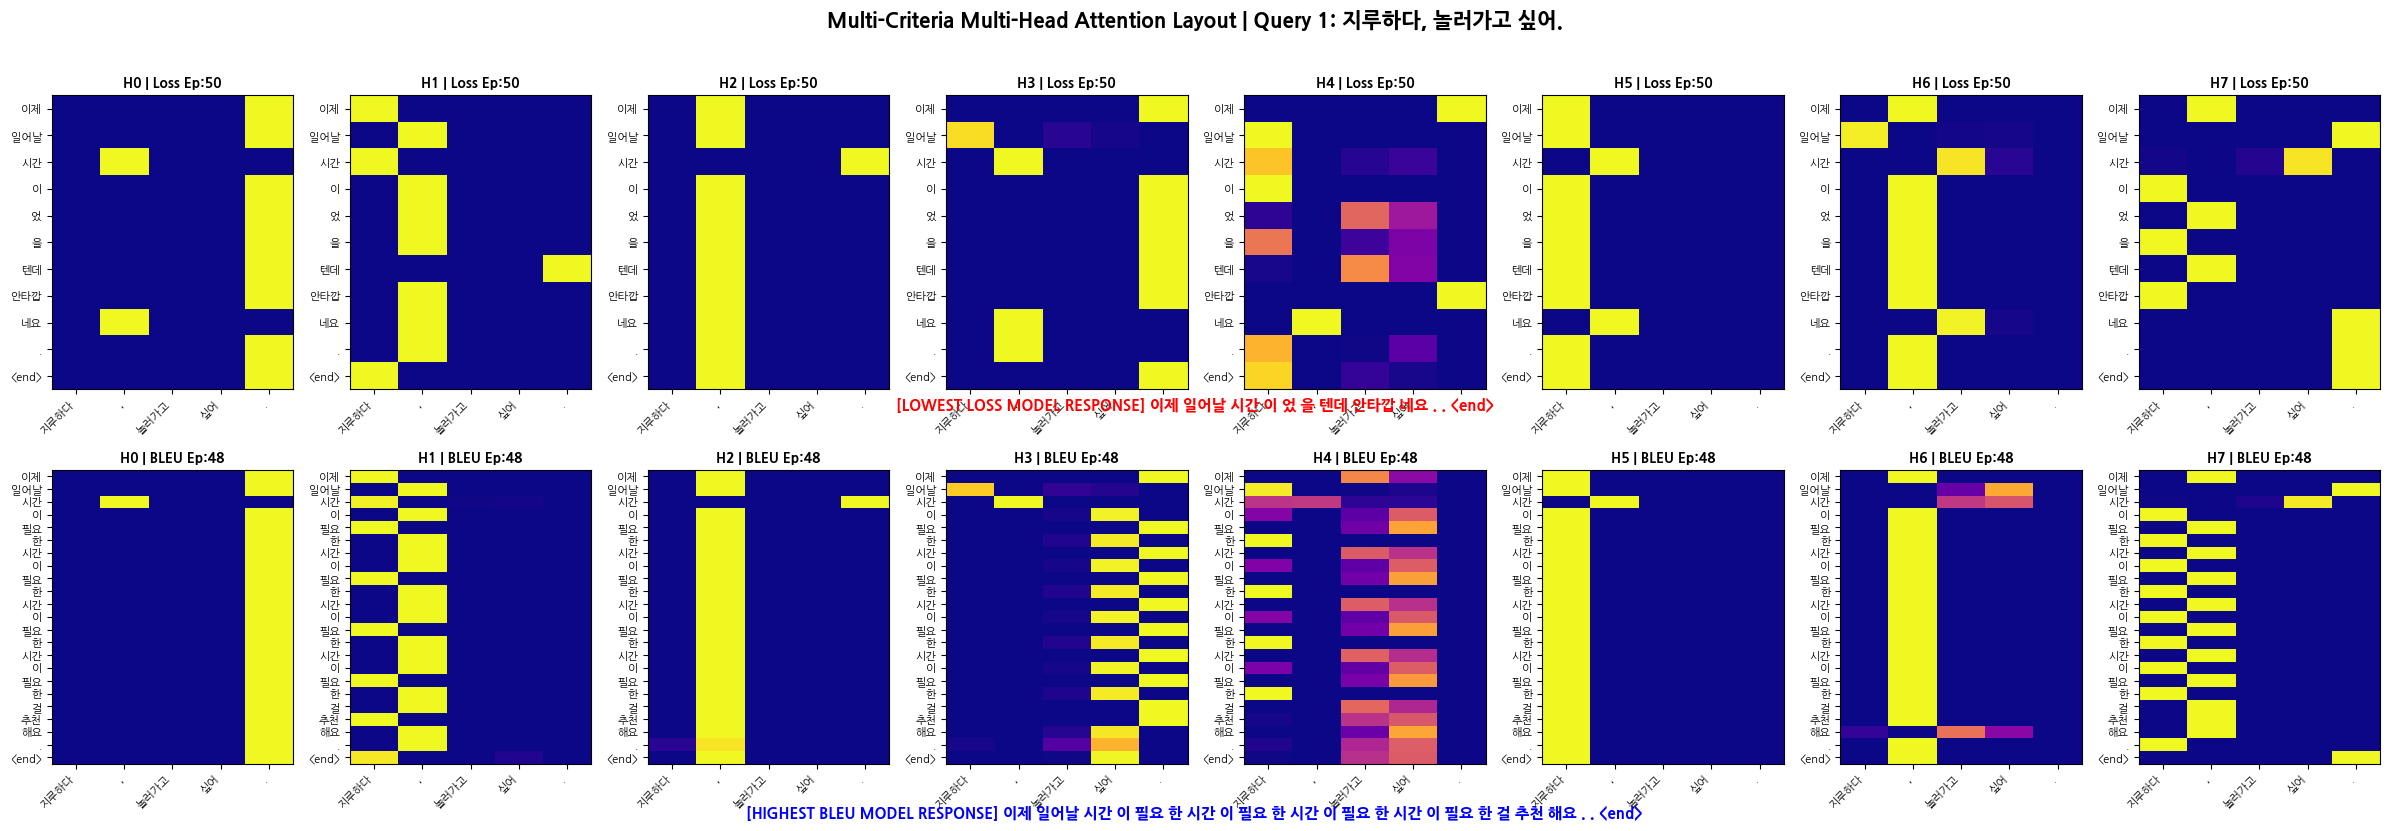

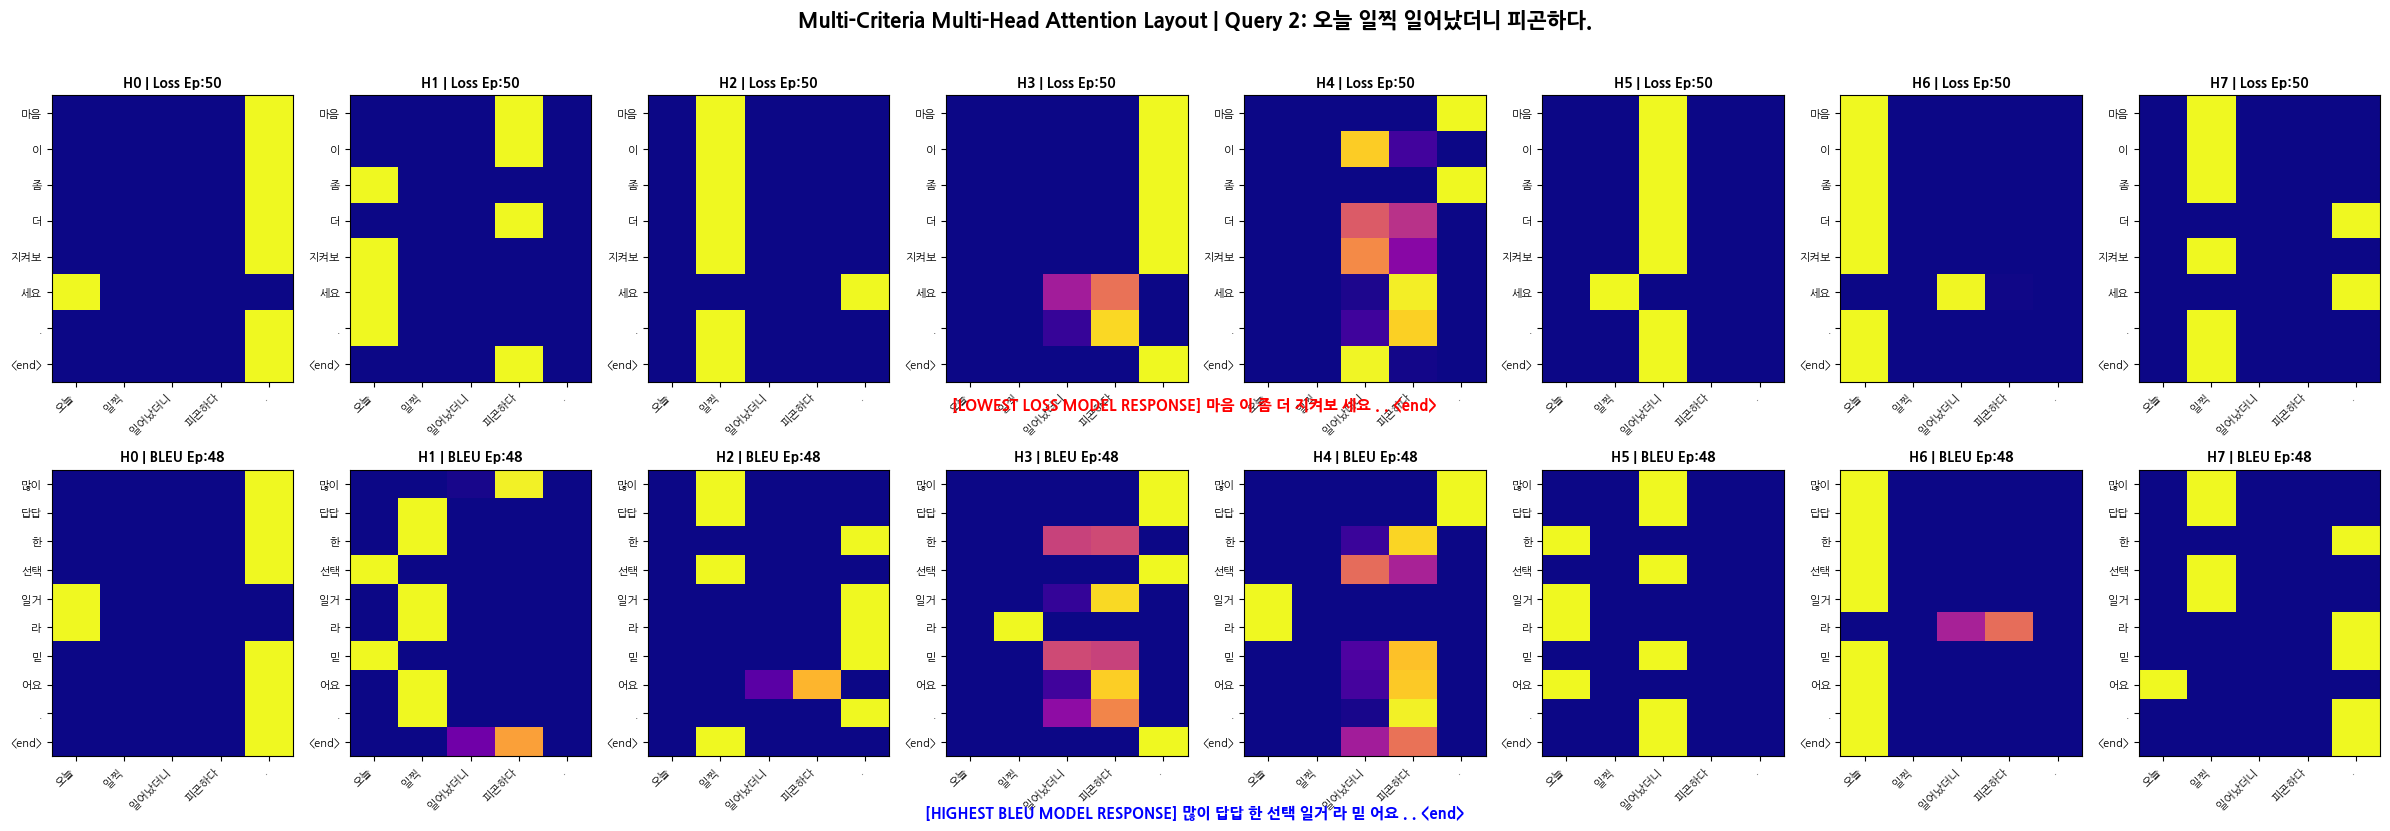

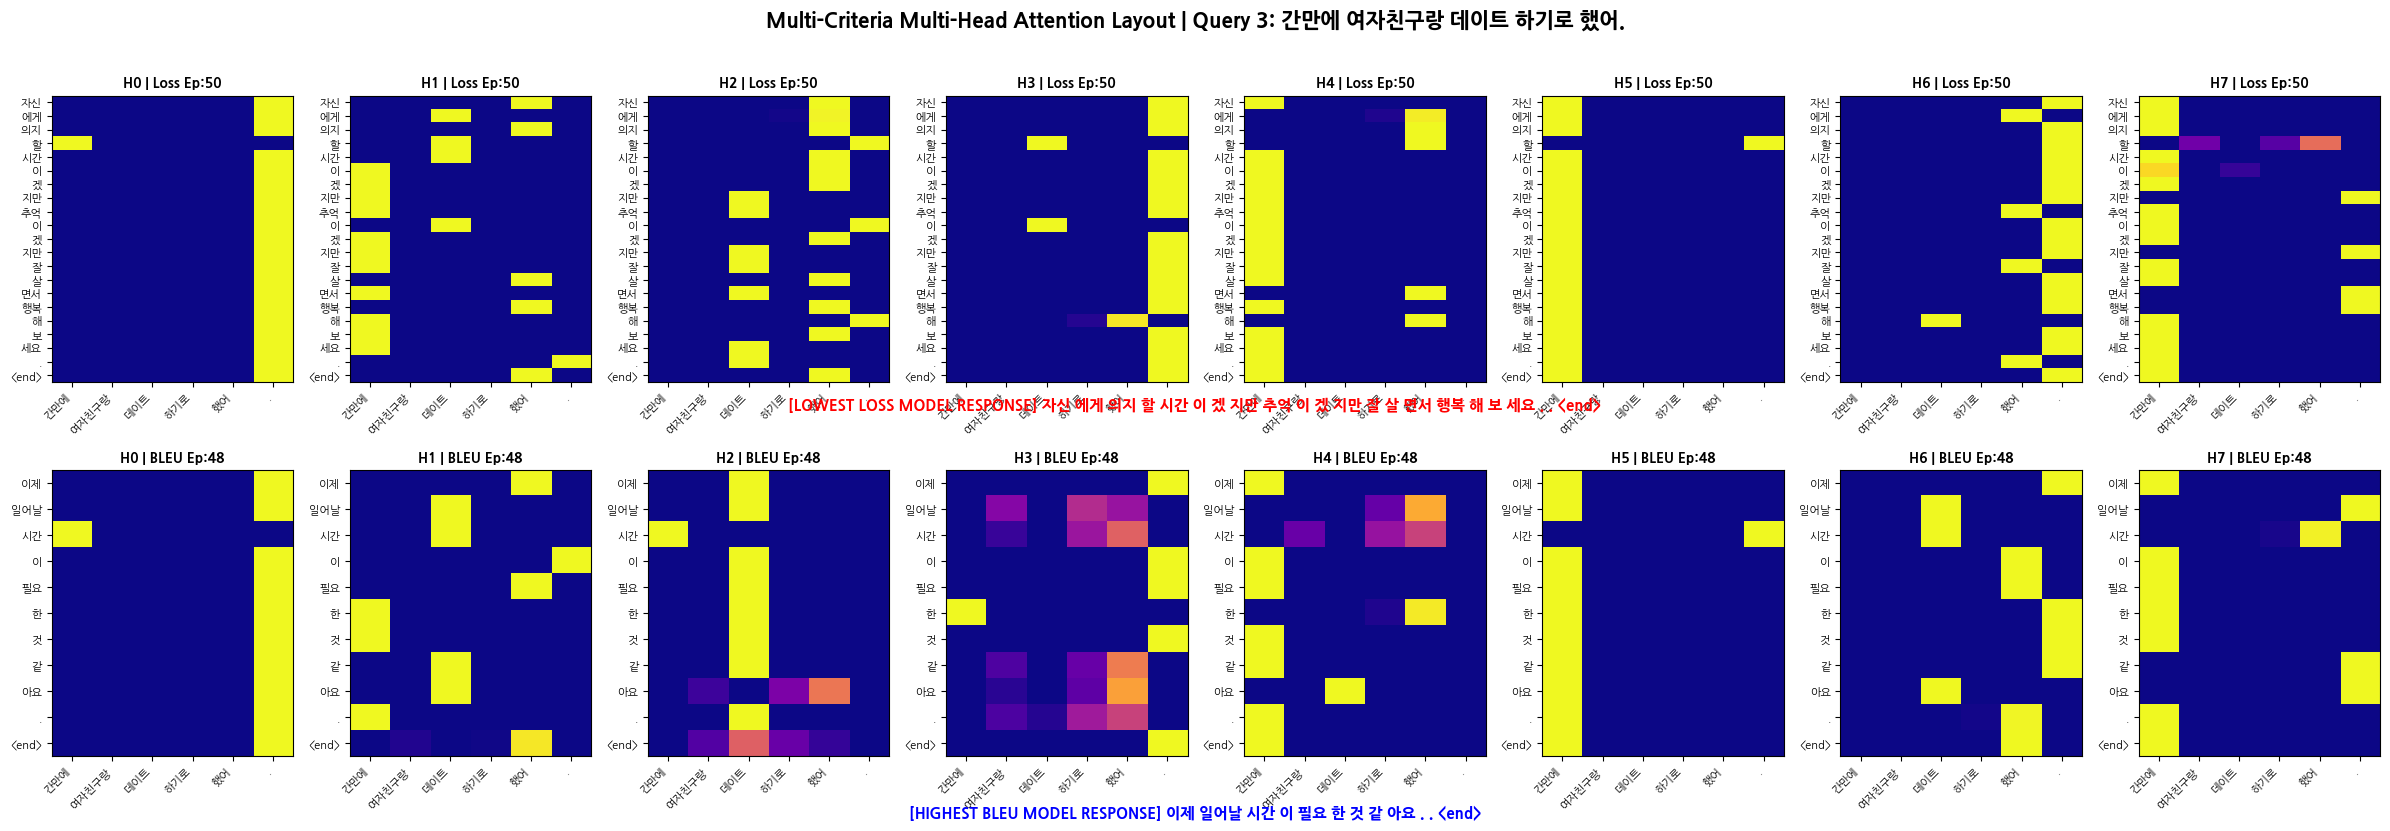

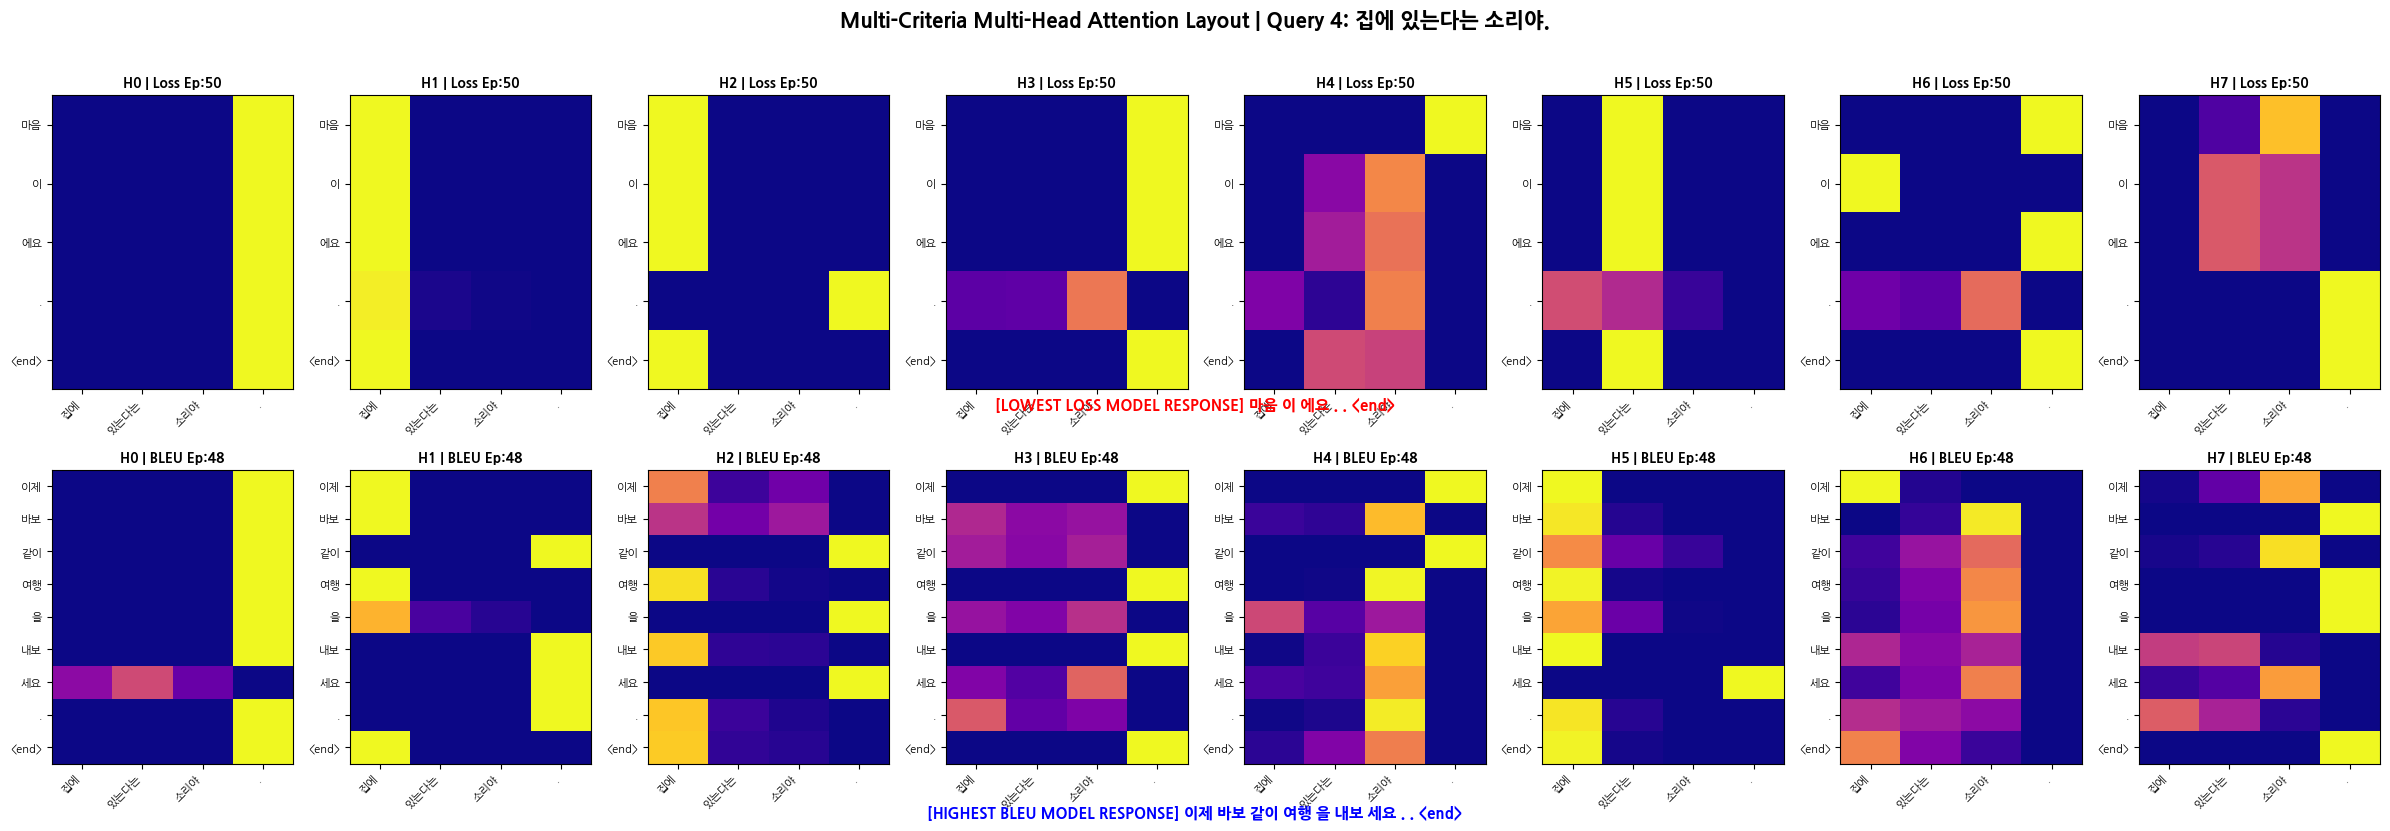


All criteria comparisons for the 8-head alignment tracks rendered successfully.


In [ ]:
# -------------------------------------------------------------------------
# Multi-Criteria (Best Loss vs Best BLEU) 8-Head Attention Plotter
# -------------------------------------------------------------------------
# Loops through the 4 queries to build a 2-tier matrix display per sentence.
# Top Row    : 8-Head Cross-Attention Maps from the Lowest Val Loss Epoch
# Bottom Row : 8-Head Cross-Attention Maps from the Highest BLEU Score Epoch
# -------------------------------------------------------------------------

def extract_cross_attention_multi_heads(model, src_tensor, word_map, max_len=30):
    """
    Performs evaluation inference, capturing Cross-Attention matrices 
    for all 8 heads from the uppermost layer configuration.
    """
    model.eval()
    tgt_indices = [word_map["<start>"]]
    final_dec_enc_attn = None
    
    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=src_tensor.device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            # Forward pass execution
            _, _, _, dec_enc_attns = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            
            # Isolate the uppermost layered multi-head cross attention tensor [num_heads, q_len, k_len]
            final_dec_enc_attn = dec_enc_attns[-1][0].cpu().numpy()
            
            next_token_idx = torch.argmax(model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)[0][0, -1, :]).item()
            tgt_indices.append(next_token_idx)
            if next_token_idx == word_map["<end>"]:
                break
                
    return tgt_indices, final_dec_enc_attn


print("\n--> Initiating Multi-Criteria 8-Head Grid Attention Mapping Sessions...")

# Core looping execution across the targeted 4 query statements
for idx, raw_query in enumerate(submission_queries, 1):
    
    # 1. VECTORIZATION: Parse pure text strings directly preventing runtime tokenizer mismatches
    sanitized_query = raw_query.replace(",", " ,").replace(".", " .").replace("?", " ?")
    source_tokens = sanitized_query.split()
    encoded_src = [word_to_index.get(word, word_to_index["<unk>"]) for word in source_tokens]
    
    MAX_PADDING_BOUND = 25
    if len(encoded_src) < MAX_PADDING_BOUND:
        encoded_src += [0] * (MAX_PADDING_BOUND - len(encoded_src))
    else:
        encoded_src = encoded_src[:MAX_PADDING_BOUND]
        
    src_eval_tensor = torch.tensor([encoded_src], dtype=torch.long, device=device)
    
    # 2. DATA CAPTURE - LOWEST LOSS MODULE
    loss_checkpoint = torch.load(loss_weight_path, map_location=device)
    comp_transformer.load_state_dict(loss_checkpoint['model_state_dict'])
    loss_tgt_idx, loss_attn_matrix = extract_cross_attention_multi_heads(comp_transformer, src_eval_tensor, word_to_index)
    loss_pred_words = [index_to_word[i] for i in loss_tgt_idx]
    
    # 3. DATA CAPTURE - HIGHEST BLEU MODULE
    bleu_checkpoint = torch.load(bleu_weight_path, map_location=device)
    comp_transformer.load_state_dict(bleu_checkpoint['model_state_dict'])
    bleu_tgt_idx, bleu_attn_matrix = extract_cross_attention_multi_heads(comp_transformer, src_eval_tensor, word_to_index)
    bleu_pred_words = [index_to_word[i] for i in bleu_tgt_idx]
    
    # 4. GRID CANVAS ARCHITECTURE: Build a strict 2-rows by 8-columns plot layout panel
    fig, axs = plt.subplots(2, 8, figsize=(24, 8))
    
    q_len_enc = len(source_tokens)
    num_heads = 8
    
    # Render processing channels loop
    for head in range(num_heads):
        # Establish dynamic shape slices discarding zero padding
        q_len_dec_loss = len(loss_pred_words) - 1
        q_len_dec_bleu = len(bleu_pred_words) - 1
        
        matrix_loss_slice = loss_attn_matrix[head, :q_len_dec_loss, :q_len_enc]
        matrix_bleu_slice = bleu_attn_matrix[head, :q_len_dec_bleu, :q_len_enc]
        
        # ---------------------------------------------------------------------
        # TIER 1 (TOP ROW): Lowest Val Loss Cross-Attention (8 Heads Side-by-Side)
        # ---------------------------------------------------------------------
        axs[0, head].imshow(matrix_loss_slice, cmap="plasma", aspect="auto")
        axs[0, head].set_title(f"H{head} | Loss Ep:{loss_ep}", fontsize=10, fontweight="bold")
        axs[0, head].set_xticks(range(q_len_enc))
        axs[0, head].set_xticklabels(source_tokens, rotation=45, ha="right", fontsize=8)
        axs[0, head].set_yticks(range(q_len_dec_loss))
        axs[0, head].set_yticklabels(loss_pred_words[1:], fontsize=8)
        
        # ---------------------------------------------------------------------
        # TIER 2 (BOTTOM ROW): Highest BLEU Cross-Attention (8 Heads Side-by-Side)
        # ---------------------------------------------------------------------
        axs[1, head].imshow(matrix_bleu_slice, cmap="plasma", aspect="auto")
        axs[1, head].set_title(f"H{head} | BLEU Ep:{bleu_ep}", fontsize=10, fontweight="bold")
        axs[1, head].set_xticks(range(q_len_enc))
        axs[1, head].set_xticklabels(source_tokens, rotation=45, ha="right", fontsize=8)
        axs[1, head].set_yticks(range(q_len_dec_bleu))
        axs[1, head].set_yticklabels(bleu_pred_words[1:], fontsize=8)
        
    # Compile text captions summarizing the performance characteristics below the blocks
    clean_loss_txt = " ".join(loss_pred_words[1:-1])
    clean_bleu_txt = " ".join(bleu_pred_words[1:-1])
    
    fig.text(0.5, 0.52, f"[LOWEST LOSS MODEL RESPONSE] {clean_loss_txt} . <end>", ha="center", fontsize=11, color="red", fontweight="bold")
    fig.text(0.5, 0.01, f"[HIGHEST BLEU MODEL RESPONSE] {clean_bleu_txt} . <end>", ha="center", fontsize=11, color="blue", fontweight="bold")
    
    plt.suptitle(f"Multi-Criteria Multi-Head Attention Layout | Query {idx}: {raw_query}", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show() # Push raw graphics pipelines directly into the running ipynb notebook cell context

print("\nAll criteria comparisons for the 8-head alignment tracks rendered successfully.")

### Head-by-Head Cross-Attention Mechanics: Epoch 50 (Lowest Loss) vs. Epoch 48 (Highest BLEU)


#### 1. What This Visualization Represents and How to Interpret It

This matrix grid visualizes the internal routing of **Cross-Attention (Encoder-Decoder Attention)** across 8 independent subspaces, known as **Heads ($H0$ to $H7$)**. It captures exactly how the Transformer decoder extracts features from the source query (X-axis: "지루하다, 놀러가고 싶어.") at each step of generating the response (Y-axis).

**Interpretation of Color and Resolution Patterns**

* **Why Epoch 48 (BLEU) Appears Gritty and Highly Fragmented (Splintered):**
  * The Y-axis (Target Generation) for Epoch 48 is significantly longer because it is trapped in an autoregressive loop, continuously spitting out the same sequence (*"이 필요 한 시간..."*). Because the generation length is extended, the matrix grid is divided into many more rows, making the individual attention pixels look **smaller, densely packed, and highly fragmented**.
* **Why Pink/Purple Tones Are More Dominant in Epoch 48:**
  * The color mapping goes from **Yellow (Maximum Attention = $1.0$)** to **Pink/Purple (Intermediate Attention = $0.3 \sim 0.5$)**, and down to **Dark Blue (Zero Attention = $0.0$)**.
  * In Epoch 48, because the model is repeating the same words over and over, the cross-attention layers suffer from **attention smearing (entropy dispersion)**. Instead of confidently pinpointing a specific source word (which would show as sharp, isolated yellow blocks), the model spreads its attention weights thinly across multiple tokens out of uncertainty. This widespread, medium-intensity attention manifests visually as large fields of pink and purple.
* **Why Epoch 50 (Loss) Appears Sharp and Blocky:**
  * Epoch 50 generates a concise, normally terminated sentence, resulting in fewer rows on the Y-axis and a larger pixel block size. The attention is **sparse and high-contrast**—mostly absolute yellow (complete focus) or solid dark blue (complete exclusion)—proving that the model has resolved its uncertainty.


#### 2. Structural Head-by-Head Comparison

The 8 attention heads do not perform the same task. They split into specialized functional groups, and their behavioral differences explain the 2-epoch gap.

**Group A: The Positional Anchors (Heads 1, 2, and 6)**

* **Epoch 50 (Lowest Loss):** These heads show solid vertical yellow bars localized entirely on the final columns (special/punctuation tokens). They act as standard global anchors, providing structural layout without interfering with word choices.
* **Epoch 48 (Highest BLEU):** They maintain a similar structural vertical tracking, showing that basic positional formatting is successfully learned early in both checkpoints.

**Group B: The Repetition Generators (Heads 4 and 7)**

* **Epoch 48 (Highest BLEU) – *The Zebra-Stripe Trap*:** Heads 4 and 7 display a distinct, rhythmic **horizontal zebra-stripe pattern** (alternating stripes of yellow, pink, and dark blue). This is the visual blueprint of the repetition loop. The heads are pulsing in a strict rhythm, locked into a mathematical loop that forces the decoder to repeat the exact same output tokens.
* **Epoch 50 (Lowest Loss) – *The Loop Mitigation*:** In Epoch 50, this repetitive pulsing is completely broken. Head 4 transitions into a smooth, non-repeating gradient, and Head 7 drops the looping matrix entirely, allowing the decoder to emit the `<end>` token naturally.

**Group C: The Semantic Extractors (Heads 0, 3, and 5)**

* **Epoch 50 (Lowest Loss) – *Targeted Attention*:** Heads 0 and 5 exhibit sharp, isolated yellow square blocks right in the middle of the sentence generation. For example, when generating the core response, these heads dynamically look back and lock onto the source keywords **"지루하다"** (Bored) and **"놀러가고"** (Want to play).
* **Epoch 48 (Highest BLEU) – *Semantic Blindness*:** In the bottom row, these specific targeting blocks are missing or completely faded into purple sheets. Head 3 is almost entirely dark blue (inactive), meaning it completely fails to register the user's emotional state, causing the model to output a generic, looping phrase instead of a contextually tailored answer.

## Conclusion


### **A. Overall Observations**

* **Insufficiency of 50-Epoch Execution Window**:
  * While the training curves demonstrate smooth convergence, neither the validation accuracy nor the Corpus BLEU-4 score fully plateaued by Epoch 50. The model was still actively optimizing, proving that 50 epochs are insufficient to capture global semantic mapping and that expanding the training budget is strictly necessary.


* **The Microscopic 2-Epoch Disconnect (The BLEU Paradox)**:
  * A critical divergence was discovered between Epoch 48 and Epoch 50. Despite being a mere 2-epoch gap, the qualitative fluency and internal attention layouts varied radically:
    * **Epoch 48 (Highest BLEU)** suffered from structural collapse, where specific heads triggered an autoregressive repetition loop by mathematically hacking high-frequency n-grams.
    * **Epoch 50 (Lowest Loss)** effectively suppressed these repetitive probability spikes, forcing the network to converge into a clean, stable diagonal generation flow.


### **B. KPT Framework**

#### **1. Keep**

* **Dual-Attention Diagnostic Pipeline**: 
  * Maintain the multi-head visualization framework (Self-Attention and Cross-Attention profiles). Tracking internal matrix structures (e.g., detecting the zebra-stripe pattern vs. clean diagonals) provides an indispensable debugging tool that corpus-level metrics like BLEU completely hide.
* **Multi-Criteria Checkpoint Selection**: 
  * Retain the practice of saving both the *Lowest Validation Loss* and *Highest BLEU* checkpoints. Comparing these boundaries is vital to diagnosing exposure bias and avoiding the deployment of degenerated looping models.

#### **2. Problem**

* **Autoregressive Loop Vulnerability**: 
  * Under Greedy Search decoding, the model remains highly susceptible to local probability traps. A minor micro-step variance in a single token can trigger catastrophic path bifurcation, forcing attention heads to pulse rhythmically and endlessly repeat phrases.
* **Semantic Blindness in Cross-Attention Subspaces**: 
  * Certain attention heads (e.g., Head 3) failed to activate or distribute weights properly, remaining smeared or locked onto the final padding column. This shows the model struggles to isolate semantic triggers within abstract or compact user queries.

#### **3. Try**

* **Statistical Tokenization via SentencePiece**: 
  * Transition to SentencePiece with a larger vocabulary size. This will allow the network to handle rare technical terms through data-driven subword statistics, eliminating out-of-vocabulary (OOV) fracturing and stabilizing the cross-attention alignment fields.
* **Massive Corpus Scaling & Deepening Architectures**: 
  * Significantly scale up the volume of the parallel training dataset. With a larger, more diverse dataset, we aim to scale up model capacity by increasing the number of Transformer layers and heads, testing how hyperparameter scaling alters structural convergence.
* **Advanced Decoding Exploration**: 
  * Introduce Beam Search or Nucleus (Top-$p$) Sampling during the inference phase to explore broader probability spaces, preventing the decoder from falling into local, greedy repetition loops.